In [1]:
import os
import re
import time
import numpy as np
import copy
import json  
import h5py
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm as tqdm
import lisabeta
import lisabeta.pyconstants as pyconstants
import lisabeta.tools.pytools as pytools
import lisabeta.tools.pyspline as pyspline
import lisabeta.tools.pyoverlap as pyoverlap
import lisabeta.lisa.pyresponse as pyresponse
import lisabeta.lisa.lisatools as lisatools
import lisabeta.lisa.snrtools as snrtools

from gbgpu.gbgpu import GBGPU
from gbgpu.thirdbody import GBGPUThirdBody

from gbgpu.utils.constants import *
from gbgpu.utils.utility import *

from Noise import AnalyticNoise
from scipy.stats import truncnorm



import ptemcee

In [2]:
dt = 15.0     
Tobs = 1* YEAR 
N = 128
df = 1/Tobs

f_central = 0.004821699107149872
f_moins = f_central - 64*df
f_plus = f_central + 64*df

print(f"{f_central:.4e}")
print(f"{f_moins:.4e}")
print(f"{f_plus:.4e}")
print(64*df)


amp1 = 2e-23  # amplitude
f01 = 4e-3  # f0
fdot1 = 1e-16  # fdot
fddot1 = 0.0 # fddot
phi01 = 0  # initial phase
iota1 = 0 #np.pi/2  # inclination
psi1 = 0 # polarization angle
lam1 = 0  # ecliptic longitude
beta1 = 0  # ecliptic latitude


params = np.array(
    [amp1, f01, fdot1, fddot1, phi01, iota1, psi1, lam1, beta1,]
)

gb = GBGPU(use_gpu=False)
gb.run_wave(*params, N=N, dt=dt, T=Tobs, oversample=2)
A = gb.A[0] 
E = gb.E[0]

noise = AnalyticNoise(f01)
psd_A = noise.psd(option="A")
asd_A = np.sqrt(psd_A)
psd_E = noise.psd(option="E")



# ET = asd_A /np.sqrt(4 * df)


# re = ET*np.random.normal(0,1,size=A.shape)
# im = ET*np.random.normal(0,1,size=A.shape)

# bruit = re +1j*im

# onde_blanchit = A*np.sqrt(4 * df) / asd_A
# onde_blanchit = np.hstack((onde_blanchit.real, onde_blanchit.imag))
# res = onde_blanchit + np.random.normal(0,1,size=onde_blanchit.shape)

# plt.plot(onde_blanchit)
# plt.plot(res)

SNR2 = 4.0 * df * np.sum( np.abs(A)**2 / psd_A ) + 4.0 * df * np.sum( np.abs(E)**2 / psd_E )
SNR = np.sqrt(SNR2)
print(SNR2)
print(SNR)




dt = 15.0     
Tobs = 1* YEAR 
N = 128
df = 1/Tobs

gb = GBGPU(use_gpu=False)
def SNR_calculus(amp, f0, fdot, phi0, iota, psi, lam, beta, dt, N, Tobs):
    df = 1/Tobs
    params = np.array([amp, f0, fdot, 0, phi0, iota, psi, lam, beta,])
    gb.run_wave(*params, N=N, dt=dt, T=Tobs, oversample=2)
    A = gb.A[0] 
    E = gb.E[0]
    noise = AnalyticNoise(f0)
    psd = noise.psd(option="A")
    SNR2 = 4.0 * df * np.sum( np.abs(A)**2 / psd ) + 4.0 * df * np.sum( np.abs(E)**2 / psd)
    SNR = np.sqrt(SNR2)
    return SNR


# print(SNR_calculus(amp1, f01, fdot1, phi01, iota1, psi1, lam1, beta1, dt, N, Tobs))



4.8217e-03
4.8197e-03
4.8237e-03
2.0345052083333333e-06
1207.7574564035135
34.752805014897916


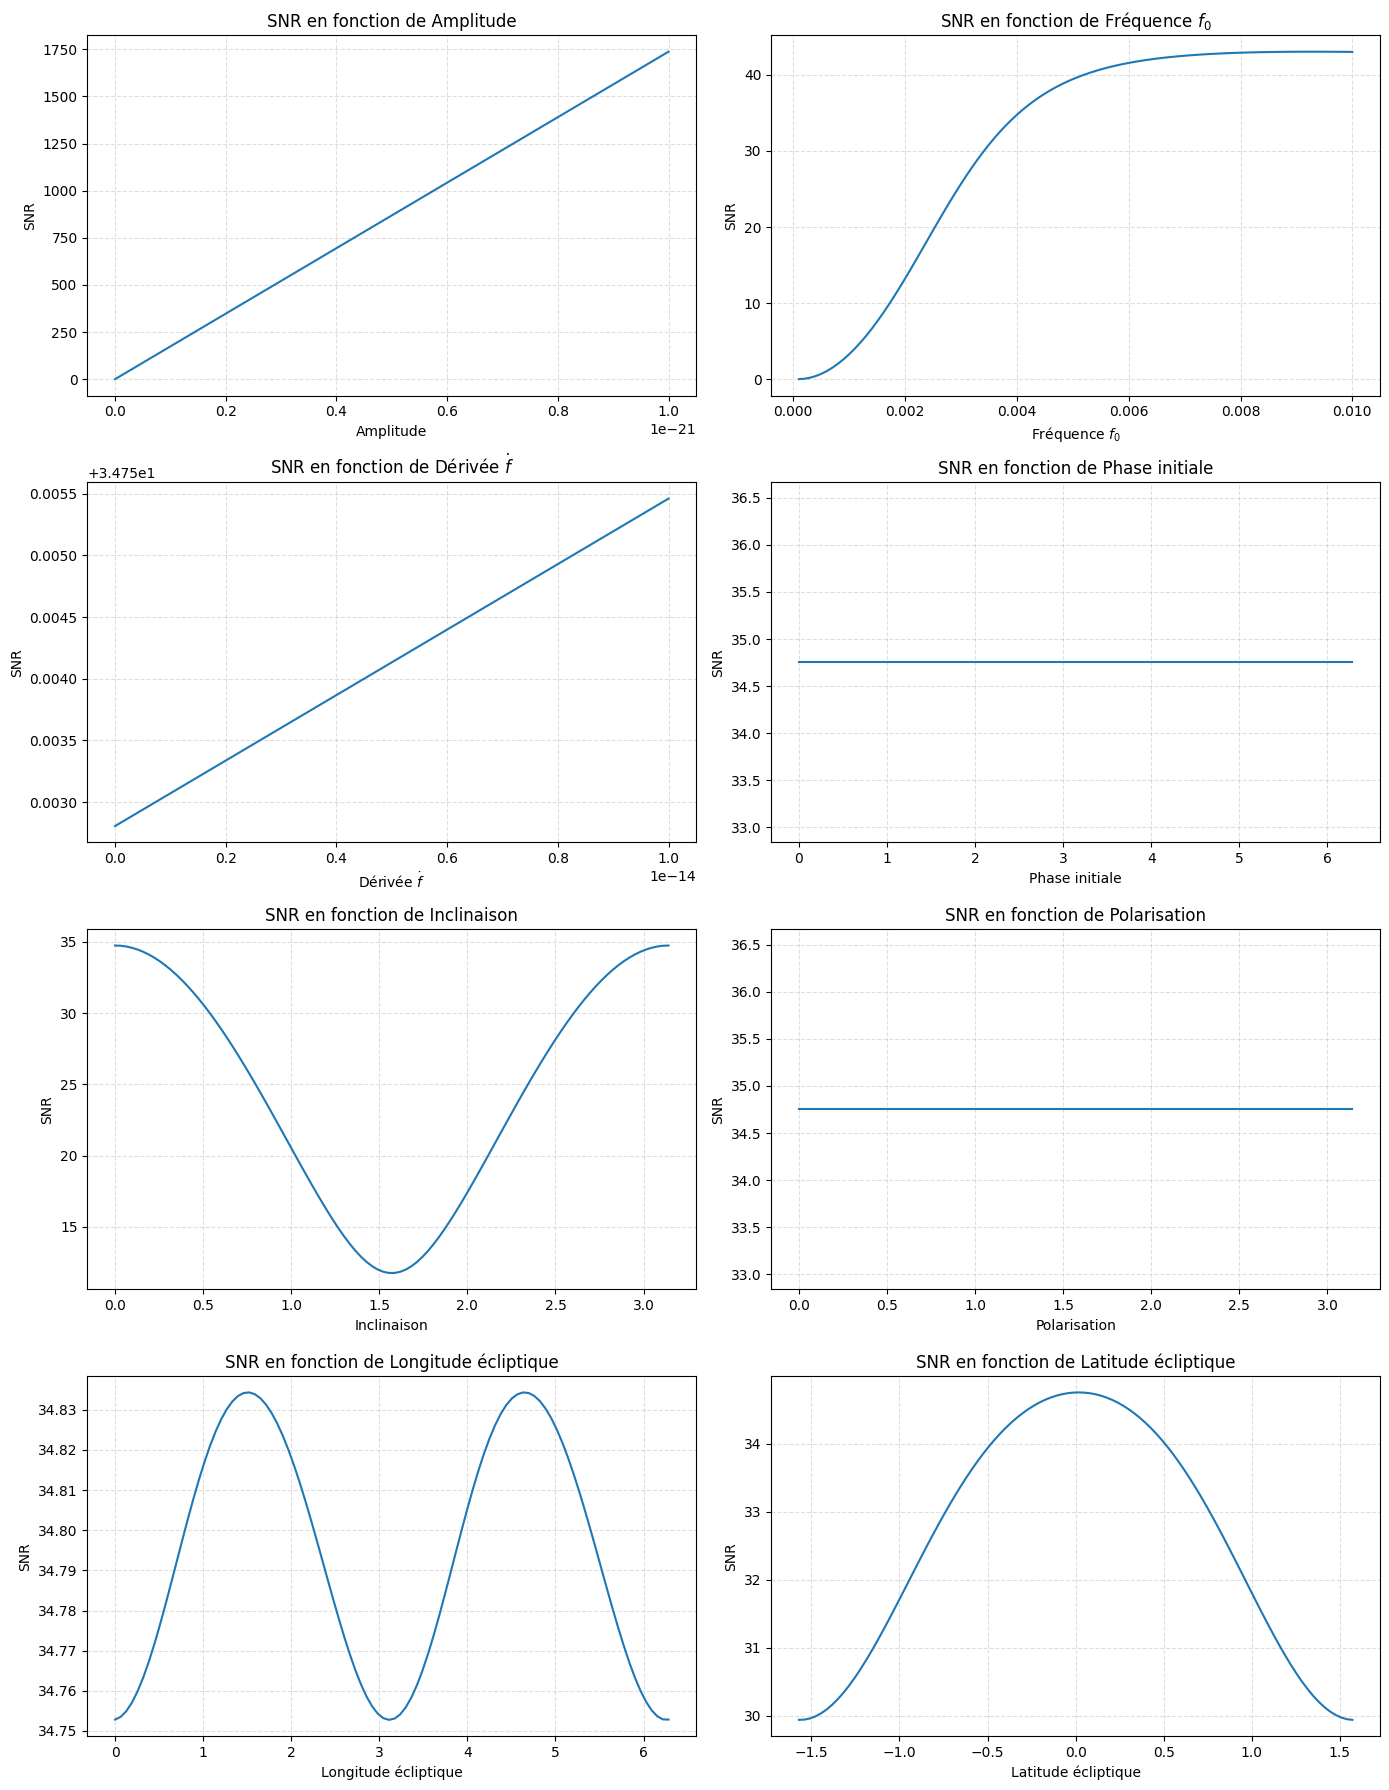

In [3]:
N = 100

# --- Paramètres de référence ---
amp0  = amp1
f00   = f01
fd0   = fdot1
phi00 = phi01
iota0 = iota1
psi0  = psi1
lam0  = lam1
beta0 = beta1


# --- Vecteurs de variations pour les 8 paramètres ---
amps  = np.logspace(-25, -21, N)
f0s   = np.linspace(1e-4, 1e-2, N)
fdots = np.logspace(-21, -14, N)
phi0s = np.linspace(0, 2*np.pi, N)
iotas = np.linspace(0, np.pi, N)
psis  = np.linspace(0, np.pi, N)
lams  = np.linspace(0, 2*np.pi, N)
betas = np.linspace(-np.pi/2, np.pi/2, N)

# Stockage des courbes
curves = [
    ("Amplitude", amps),
    ("Fréquence $f_0$", f0s),
    ("Dérivée $\\dot{f}$", fdots),
    ("Phase initiale", phi0s),
    ("Inclinaison", iotas),
    ("Polarisation", psis),
    ("Longitude écliptique", lams),
    ("Latitude écliptique", betas),
]

# --- Création de la figure 4 x 2 ---
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, (name, values) in zip(axes, curves):
    
    SNR_vals = []

    for val in values:
        # Chaque courbe modifie UN paramètre
        SNR_vals.append(
            SNR_calculus(
                amp = val           if name=="Amplitude" else amp0,
                f0  = val           if name=="Fréquence $f_0$" else f00,
                fdot= val           if name=="Dérivée $\\dot{f}$" else fd0,
                phi0= val           if name=="Phase initiale" else phi00,
                iota= val           if name=="Inclinaison" else iota0,
                psi = val           if name=="Polarisation" else psi0,
                lam = val           if name=="Longitude écliptique" else lam0,
                beta= val           if name=="Latitude écliptique" else beta0,
                dt=dt, N=N, Tobs=Tobs
            )
        )

    SNR_vals = np.array(SNR_vals)

    # Tracé
    ax.plot(values, SNR_vals)
    ax.set_xlabel(name)
    ax.set_ylabel("SNR")
    ax.set_title(f"SNR en fonction de {name}")
    ax.grid(True, ls="--", alpha=0.4)
    # ax.set_Oscale("log")   # SNR souvent log utile

plt.tight_layout()
plt.show()


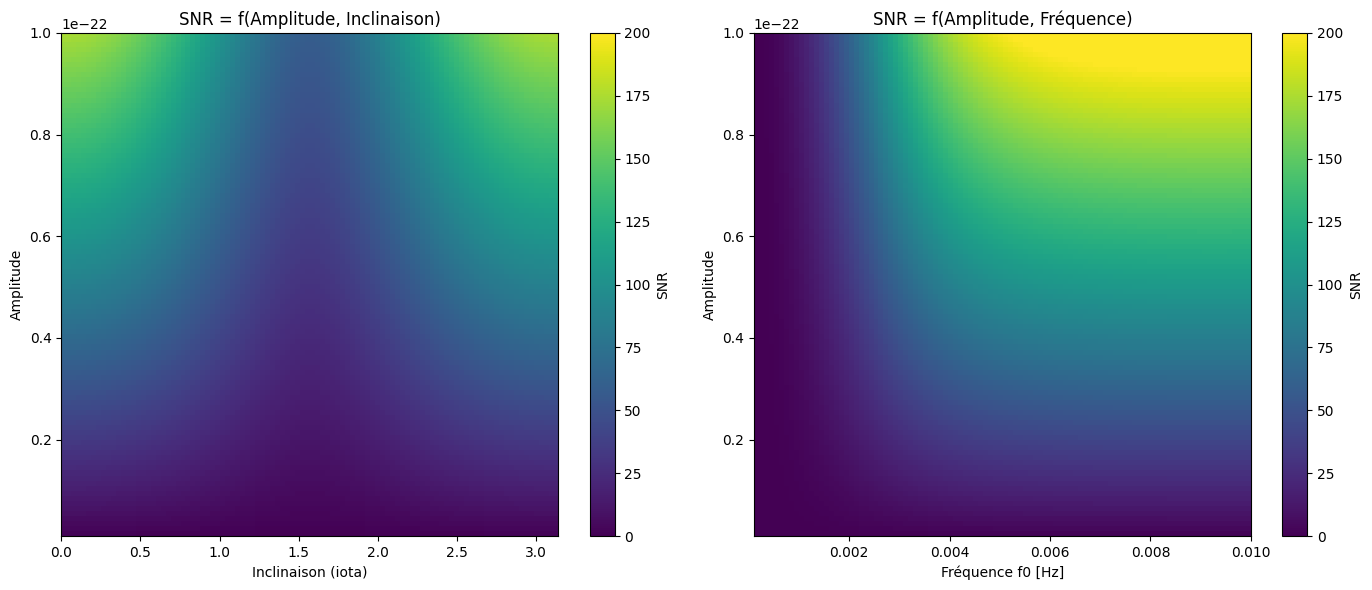

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres fixes
dt = 15.0
Tobs = 1 * YEAR
N = 128

fdot1 = 1e-16
phi01 = 0
psi1 = 0
lam1 = 0
beta1 = 0

# Fonction SNR
gb = GBGPU(use_gpu=False)

def SNR_calculus(amp, f0, fdot, phi0, iota, psi, lam, beta, dt, N, Tobs):
    df = 1/Tobs
    params = np.array([amp, f0, fdot, 0, phi0, iota, psi, lam, beta])
    gb.run_wave(*params, N=N, dt=dt, T=Tobs, oversample=2)
    A = gb.A[0]
    E = gb.E[0]
    noise = AnalyticNoise(f0)
    psd = noise.psd(option="A")
    SNR2 = 4.0 * df * np.sum(np.abs(A)**2 / psd) + 4.0 * df * np.sum(np.abs(E)**2 / psd)
    return np.sqrt(SNR2)

# Plages de paramètres
amps = np.linspace(1e-24, 1e-22, 100)
iotas = np.linspace(0, np.pi, 100)
f0s = np.linspace(1e-4, 1e-2, 100)

# Matrices pour SNR
SNR_iota = np.zeros((len(amps), len(iotas)))
SNR_f0 = np.zeros((len(amps), len(f0s)))

# Calcul SNR
for i, amp in enumerate(amps):
    for j, iota in enumerate(iotas):
        SNR_iota[i, j] = SNR_calculus(amp, f01, fdot1, phi01, iota, psi1, lam1, beta1, dt, N, Tobs)
    for j, f0 in enumerate(f0s):
        SNR_f0[i, j] = SNR_calculus(amp, f0, fdot1, phi01, iota1, psi1, lam1, beta1, dt, N, Tobs)

# --- Définir un SNR max ---
SNR_max = 200  # par exemple
SNR_iota = np.clip(SNR_iota, 0, SNR_max)
SNR_f0 = np.clip(SNR_f0, 0, SNR_max)

# Tracé des cartes de chaleur
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Amplitude vs Inclinaison ---
im1 = axes[0].imshow(SNR_iota, 
                     extent=[iotas[0], iotas[-1], amps[0], amps[-1]], 
                     origin='lower', 
                     aspect='auto', 
                     cmap='viridis',
                     vmin=0, vmax=SNR_max)
axes[0].set_xlabel('Inclinaison (iota)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('SNR = f(Amplitude, Inclinaison)')
fig.colorbar(im1, ax=axes[0], label='SNR')

# --- Amplitude vs Fréquence ---
im2 = axes[1].imshow(SNR_f0, 
                     extent=[f0s[0], f0s[-1], amps[0], amps[-1]], 
                     origin='lower', 
                     aspect='auto', 
                     cmap='viridis',
                     vmin=0, vmax=SNR_max)
axes[1].set_xlabel('Fréquence f0 [Hz]')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('SNR = f(Amplitude, Fréquence)')
fig.colorbar(im2, ax=axes[1], label='SNR')

plt.tight_layout()
plt.show()


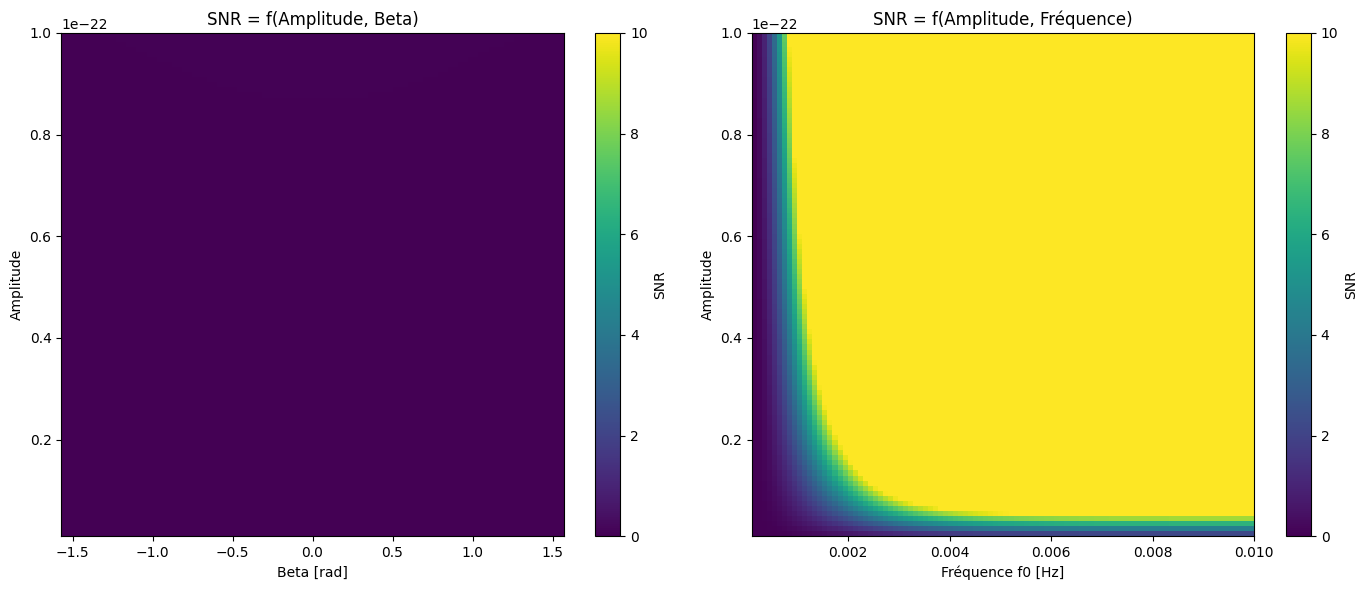

In [5]:
# Paramètres fixes
dt = 15.0
Tobs = 1 * YEAR
N = 128

f01 = 1e-4
fdot1 = 1e-16
phi01 = 0
psi1 = 0
lam1 = 0
iota1 = 0

# Fonction SNR
gb = GBGPU(use_gpu=False)

def SNR_calculus(amp, f0, fdot, phi0, iota, psi, lam, beta, dt, N, Tobs):
    df = 1/Tobs
    params = np.array([amp, f0, fdot, 0, phi0, iota, psi, lam, beta])
    gb.run_wave(*params, N=N, dt=dt, T=Tobs, oversample=2)
    A = gb.A[0]
    E = gb.E[0]
    noise = AnalyticNoise(f0)
    psd = noise.psd(option="A")
    SNR2 = 4.0 * df * np.sum(np.abs(A)**2 / psd) + 4.0 * df * np.sum(np.abs(E)**2 / psd)
    return np.sqrt(SNR2)

# Plages de paramètres
amps = np.linspace(1e-24, 1e-22, 100)
betas = np.linspace(-np.pi/2, np.pi/2, 100)  # Beta typiquement entre -π/2 et π/2
f0s = np.linspace(1e-4, 1e-2, 100)

# Matrices pour SNR
SNR_beta = np.zeros((len(amps), len(betas)))
SNR_f0 = np.zeros((len(amps), len(f0s)))

# Calcul SNR
for i, amp in enumerate(amps):
    for j, beta in enumerate(betas):
        SNR_beta[i, j] = SNR_calculus(amp, f01, fdot1, phi01, iota1, psi1, lam1, beta, dt, N, Tobs)
    for j, f0 in enumerate(f0s):
        SNR_f0[i, j] = SNR_calculus(amp, f0, fdot1, phi01, iota1, psi1, lam1, 0, dt, N, Tobs)  # beta fixé à 0 pour f0 plot

# --- Définir un SNR max ---
SNR_max = 10
SNR_beta = np.clip(SNR_beta, 0, SNR_max)
SNR_f0 = np.clip(SNR_f0, 0, SNR_max)

# Tracé des cartes de chaleur
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Amplitude vs Beta ---
im1 = axes[0].imshow(SNR_beta, 
                     extent=[betas[0], betas[-1], amps[0], amps[-1]], 
                     origin='lower', 
                     aspect='auto', 
                     cmap='viridis',
                     vmin=0, vmax=SNR_max)
axes[0].set_xlabel('Beta [rad]')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('SNR = f(Amplitude, Beta)')
fig.colorbar(im1, ax=axes[0], label='SNR')

# --- Amplitude vs Fréquence ---
im2 = axes[1].imshow(SNR_f0, 
                     extent=[f0s[0], f0s[-1], amps[0], amps[-1]], 
                     origin='lower', 
                     aspect='auto', 
                     cmap='viridis',
                     vmin=0, vmax=SNR_max)
axes[1].set_xlabel('Fréquence f0 [Hz]')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('SNR = f(Amplitude, Fréquence)')
fig.colorbar(im2, ax=axes[1], label='SNR')

plt.tight_layout()
plt.show()

In [6]:
# dt = 15.0
# Tobs = 1 * YEAR
# N = 128

# # Exemple de fréquence centrale et PSD pour LISA  # Hz, à ajuster selon ton cas
# psd = np.ones(N)  # remplacer par ton PSD réel pour le calcul

# # Ouvrir le catalogue
# catalog_gws = "/home/disc/t.delmond/Bureau/catalogue_dwds_gws_only.h5"


# with h5py.File(catalog_gws, "r+") as f:
#     # print("Clés disponibles dans le fichier :", list(f.keys()))
    
#     f0    = f["Frequency"][:]               # fréquence initiale
#     amp   = f["Amplitude"][:]               # amplitude
#     lam   = f["EclipticLongitude"][:]       # longitude écliptique
#     beta  = f["EclipticLatitude"][:]        # latitude écliptique
#     iota  = f["Inclination"][:]             # inclinaison
#     fdot  = f["FrequencyDerivative"][:]     # dérivée de la fréquence
#     psi   = f["Polarization"][:]            # polarisation
#     phi0  = f["InitialPhase"][:]            # phase initiale

#     SNR_array = np.zeros(len(f0))

#     for i in tqdm(range(len(f0)), desc="Calcul du SNR"):
#         SNR_array[i] = SNR_calculus(amp[i], f0[i], fdot[i], phi0[i], iota[i], psi[i], lam[i], beta[i], dt, N, Tobs)

#         # Ajouter le dataset SNR dans le fichier HDF5
#     if "SNR" in f:
#         del f["SNR"]  # supprimer si déjà existant
#     f.create_dataset("SNR", data=SNR_array)


In [7]:

catalog_gws = "/home/disc/t.delmond/Bureau/catalogue_dwds_gws_only.h5"

with h5py.File(catalog_gws, "r") as f:
    print("Clés disponibles dans le fichier :", list(f.keys()))
    
    f0    = f["Frequency"][:].flatten()               # fréquence initiale
    amp   = f["Amplitude"][:].flatten()              # amplitude
    lam   = f["EclipticLongitude"][:].flatten()       # longitude écliptique
    beta  = f["EclipticLatitude"][:].flatten()        # latitude écliptique
    iota  = f["Inclination"][:].flatten()             # inclinaison
    fdot  = f["FrequencyDerivative"][:].flatten()     # dérivée de la fréquence
    psi   = f["Polarization"][:].flatten()            # polarisation
    phi0  = f["InitialPhase"][:].flatten()            # phase initiale
    dL    = f["LuminosityDistance"][:].flatten()      # distance à la source
    m1    = f["PrimaryMass"][:].flatten()             # masse primaire
    m2    = f["SecondaryMass"][:].flatten()           # masse secondaire
    SNR   = f["SNR"][:].flatten()


len(f0)

Clés disponibles dans le fichier : ['Amplitude', 'EclipticLatitude', 'EclipticLongitude', 'Frequency', 'FrequencyDerivative', 'Inclination', 'InitialPhase', 'LuminosityDistance', 'Polarization', 'PrimaryMass', 'SNR', 'SecondaryMass']


7364527

In [8]:
# Filtrer selon SNR
mask = (SNR >= 5) & (SNR <= 10)

amp_sel  = amp[mask]
beta_sel = beta[mask]
iota_sel = iota[mask]

# Créer les triplets
triplets = np.vstack([amp_sel, iota_sel, beta_sel]).T

print(f"Nombre de sources avec 5 ≤ SNR ≤ 10 : {triplets.shape[0]}")
print("Exemples de triplets (amp, iota, beta) :")
print(triplets[:10])  # Affiche les 10 premiers

Nombre de sources avec 5 ≤ SNR ≤ 10 : 8363
Exemples de triplets (amp, iota, beta) :
[[ 1.05914791e-23  2.80907897e+00 -9.79049122e-01]
 [ 1.46936219e-23  8.15999643e-01 -4.46228773e-01]
 [ 2.12819531e-23  3.01406698e+00 -4.89786705e-01]
 [ 1.31192507e-23  1.00784111e+00 -7.00617792e-01]
 [ 3.80203423e-23  1.87662965e+00 -4.97531071e-01]
 [ 1.54240398e-23  1.77170831e+00 -4.92960197e-01]
 [ 1.14393812e-23  9.80680640e-01 -4.99276906e-01]
 [ 1.39465952e-23  1.39537304e+00 -4.82962110e-01]
 [ 1.11375769e-23  1.13756604e+00 -4.66083103e-01]
 [ 1.04294097e-23  5.43054713e-01 -4.60983639e-01]]


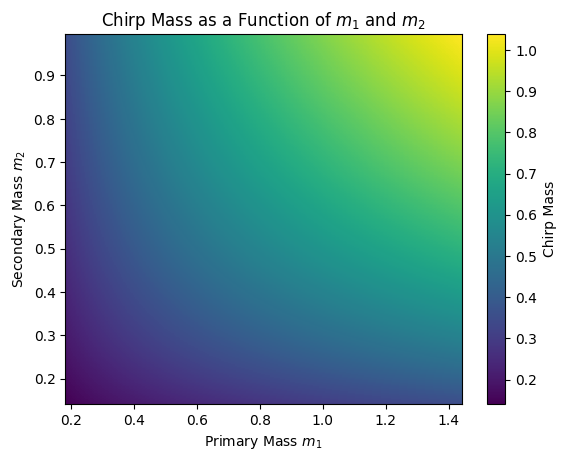

Chirp mass range: 0.14 - 1.04


In [9]:
def chirp_mass(m1, m2):
    return (m1 * m2)**(3/5) / (m1 + m2)**(1/5)

# Grid limits from your data
m1_min, m1_max = np.min(m1), np.max(m1)
m2_min, m2_max = np.min(m2), np.max(m2)

# Create grid
m1_grid = np.linspace(m1_min, m1_max, 300)
m2_grid = np.linspace(m2_min, m2_max, 300)
M1, M2 = np.meshgrid(m1_grid, m2_grid)

# Compute chirp mass
Mc = chirp_mass(M1, M2)

# Heatmap
plt.figure()
plt.pcolormesh(M1, M2, Mc, shading="auto")
plt.colorbar(label="Chirp Mass")
plt.xlabel("Primary Mass $m_1$")
plt.ylabel("Secondary Mass $m_2$")
plt.title("Chirp Mass as a Function of $m_1$ and $m_2$")
plt.show()

print(f"Chirp mass range: {np.min(Mc):.2f} - {np.max(Mc):.2f}")

9570


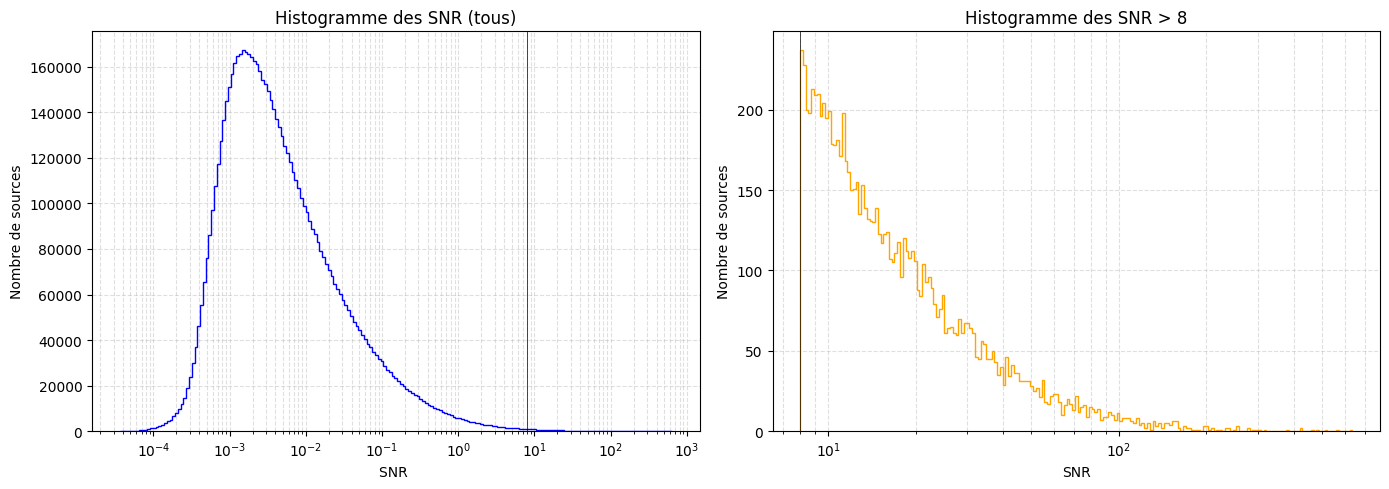

6487


In [10]:
SNR_treshold = 8
SNR_cut = SNR[SNR > SNR_treshold]
bins_all = np.geomspace(SNR.min(), SNR.max(), 200)
bins_cut = np.geomspace(SNR_cut.min(), SNR_cut.max(), 200)
print(len(SNR_cut))

# Créer la figure avec 2 sous-graphes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(SNR, bins=bins_all, histtype='step', color='blue')
axes[0].axvline(SNR_treshold, c='k', lw=0.5)
axes[0].set_xscale('log')
axes[0].set_xlabel("SNR ")
axes[0].set_ylabel("Nombre de sources")
axes[0].set_title("Histogramme des SNR (tous)")
axes[0].grid(True, which="both", ls="--", alpha=0.4)

# Graphe 2 : fréquences > 1 mHz
axes[1].hist(SNR_cut, bins=bins_cut, histtype='step', color='orange')
axes[1].axvline(SNR_treshold, c='k', lw=0.5)
axes[1].set_xscale('log')
axes[1].set_xlabel("SNR")
axes[1].set_ylabel("Nombre de sources")
axes[1].set_title(f"Histogramme des SNR > {SNR_treshold}")
axes[1].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

SNR_cut = SNR[(SNR > 8) & (SNR < 20)]
print(len(SNR_cut))

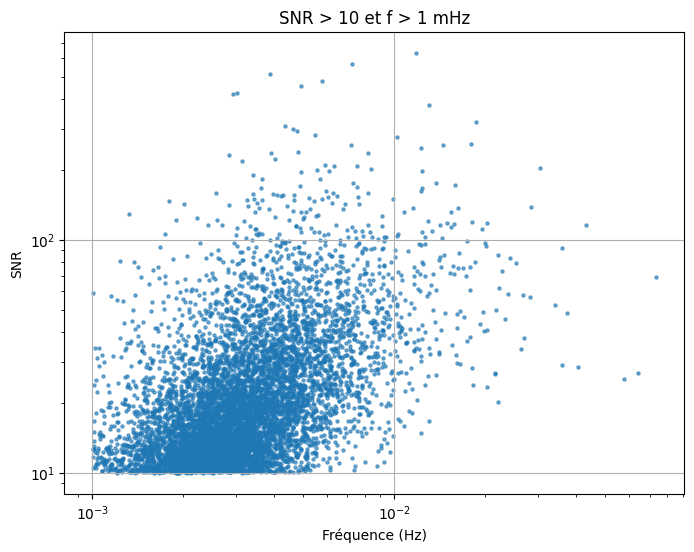

In [11]:


SNR_threshold = 10  # à adapter

# masque
mask = (SNR > SNR_threshold) & (f0 > 1e-3)

plt.figure(figsize=(8,6))

plt.scatter(f0[mask], SNR[mask], s=5, alpha=0.6)

plt.xlabel("Fréquence (Hz)")
plt.ylabel("SNR")
plt.xscale("log")
plt.yscale("log")
plt.title(f"SNR > {SNR_threshold} et f > 1 mHz")

plt.grid(True)
plt.show()

Nombre de sources dans la fenêtre : 420
Nombre de sources dans la fenêtre : 420


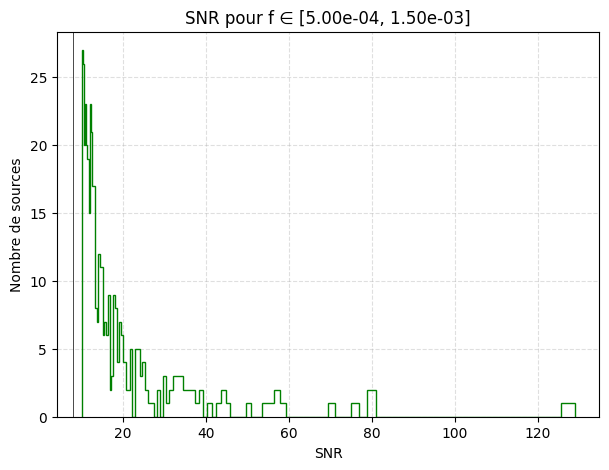

In [43]:
f_center = 0.001
df_window = 0.001
SNR_threshold = 10

# masque combiné fréquence + SNR
mask = (
    (f0 > f_center - df_window/2) &
    (f0 < f_center + df_window/2) &
    (SNR > SNR_threshold)
)

SNR_window = SNR[mask]

print("Nombre de sources dans la fenêtre :", len(SNR_window))

print("Nombre de sources dans la fenêtre :", len(SNR_window))

bins_window = np.geomspace(SNR_window.min(), SNR_window.max(), 100)

plt.figure(figsize=(7,5))
plt.hist(SNR_window, bins=bins_window, histtype='step', color='green')
plt.axvline(8, c='k', lw=0.5)

# plt.xscale('log')
plt.xlabel("SNR")
plt.ylabel("Nombre de sources")
plt.title(f"SNR pour f ∈ [{f_center - df_window/2:.2e}, {f_center + df_window/2:.2e}]")
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.show()

In [13]:
25.6 * 3.5

89.60000000000001

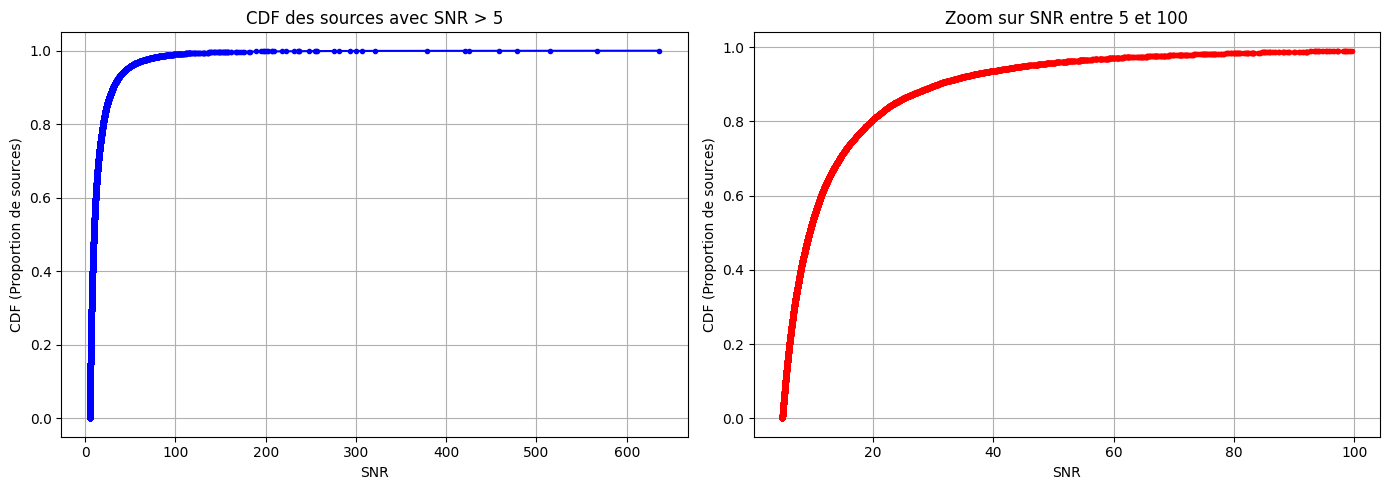

In [14]:

# Filtrer les SNR > 5
SNR_filtered = SNR[SNR > 5]

# Trier les SNR pour la CDF
SNR_sorted = np.sort(SNR_filtered)
cdf = np.arange(1, len(SNR_sorted)+1) / len(SNR_sorted)  # proportion cumulée

# Création des deux sous-graphes
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --- Graphe complet ---
axes[0].plot(SNR_sorted, cdf, marker='.', linestyle='-', color='blue')
axes[0].set_xlabel("SNR")
axes[0].set_ylabel("CDF (Proportion de sources)")
axes[0].set_title("CDF des sources avec SNR > 5")
axes[0].grid(True)

# --- Graphe zoomé SNR 5-100 ---
mask_zoom = (SNR_sorted >= 5) & (SNR_sorted <= 100)
axes[1].plot(SNR_sorted[mask_zoom], cdf[mask_zoom], marker='.', linestyle='-', color='red')
axes[1].set_xlabel("SNR")
axes[1].set_ylabel("CDF (Proportion de sources)")
axes[1].set_title("Zoom sur SNR entre 5 et 100")
axes[1].grid(True)

plt.tight_layout()
plt.show()


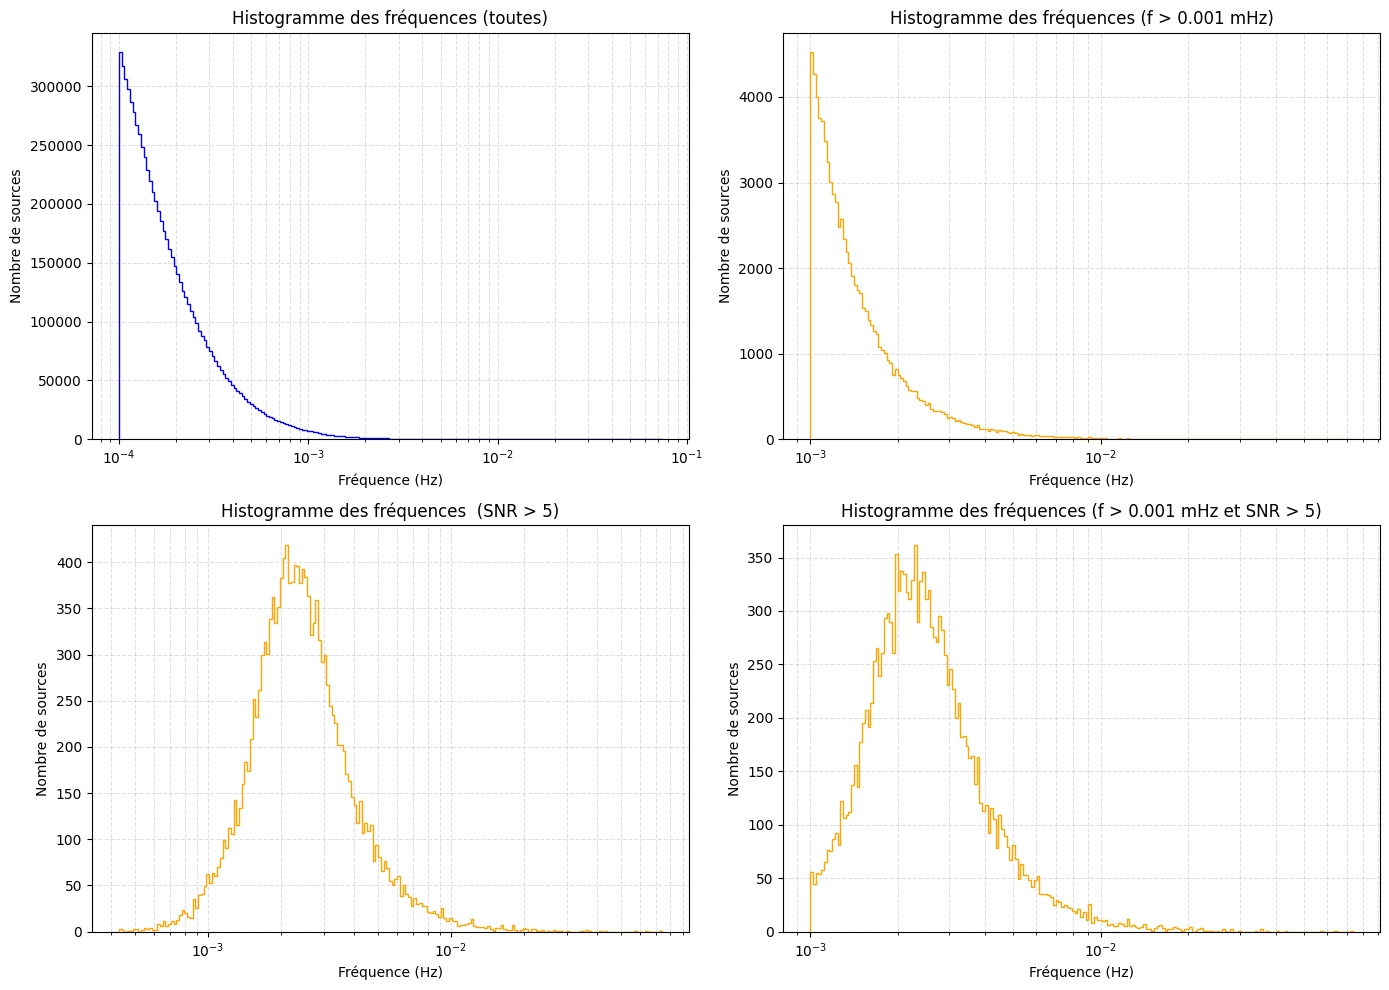

In [15]:
# Séparer les fréquences > 1 mHz
SNR_treshold = 5
f0_treshold = 1e-3
freq_cut = f0[f0 > f0_treshold]
freq_SNR = f0[(SNR > SNR_treshold)]
freq_cut_SNR = f0[(f0 > f0_treshold) & (SNR > SNR_treshold)]


# Définir des bins log pour chaque sous-graph
bins_all = np.geomspace(f0.min(), f0.max(), 200)
bins_cut = np.geomspace(freq_cut.min(), freq_cut.max(), 200)
bins_cut_SNR = np.geomspace(freq_cut_SNR.min(), freq_cut_SNR.max(), 200)
bins_SNR = np.geomspace(freq_SNR.min(), freq_SNR.max(), 200)


# Créer la figure avec 2 sous-graphes côte à côte
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Graphe 1 : toutes les fréquences
axes[0, 0].hist(f0, bins=bins_all, histtype='step', color='blue')

axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel("Fréquence (Hz)")
axes[0, 0].set_ylabel("Nombre de sources")
axes[0, 0].set_title("Histogramme des fréquences (toutes)")
axes[0, 0].grid(True, which="both", ls="--", alpha=0.4)

# Graphe 2 : fréquences > 1 mHz
axes[0, 1].hist(freq_cut, bins=bins_cut, histtype='step', color='orange')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlabel("Fréquence (Hz)")
axes[0, 1].set_ylabel("Nombre de sources")
axes[0, 1].set_title(f"Histogramme des fréquences (f > {f0_treshold} mHz)")
axes[0, 1].grid(True, which="both", ls="--", alpha=0.4)

axes[1, 0].hist(freq_SNR, bins=bins_SNR, histtype='step', color='orange')
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel("Fréquence (Hz)")
axes[1, 0].set_ylabel("Nombre de sources")
axes[1, 0].set_title(f"Histogramme des fréquences  (SNR > {SNR_treshold})")
axes[1, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[1, 1].hist(freq_cut_SNR, bins=bins_cut_SNR, histtype='step', color='orange')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel("Fréquence (Hz)")
axes[1, 1].set_ylabel("Nombre de sources")
axes[1, 1].set_title(f"Histogramme des fréquences (f > {f0_treshold} mHz et SNR > {SNR_treshold})")
axes[1, 1].grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.show()


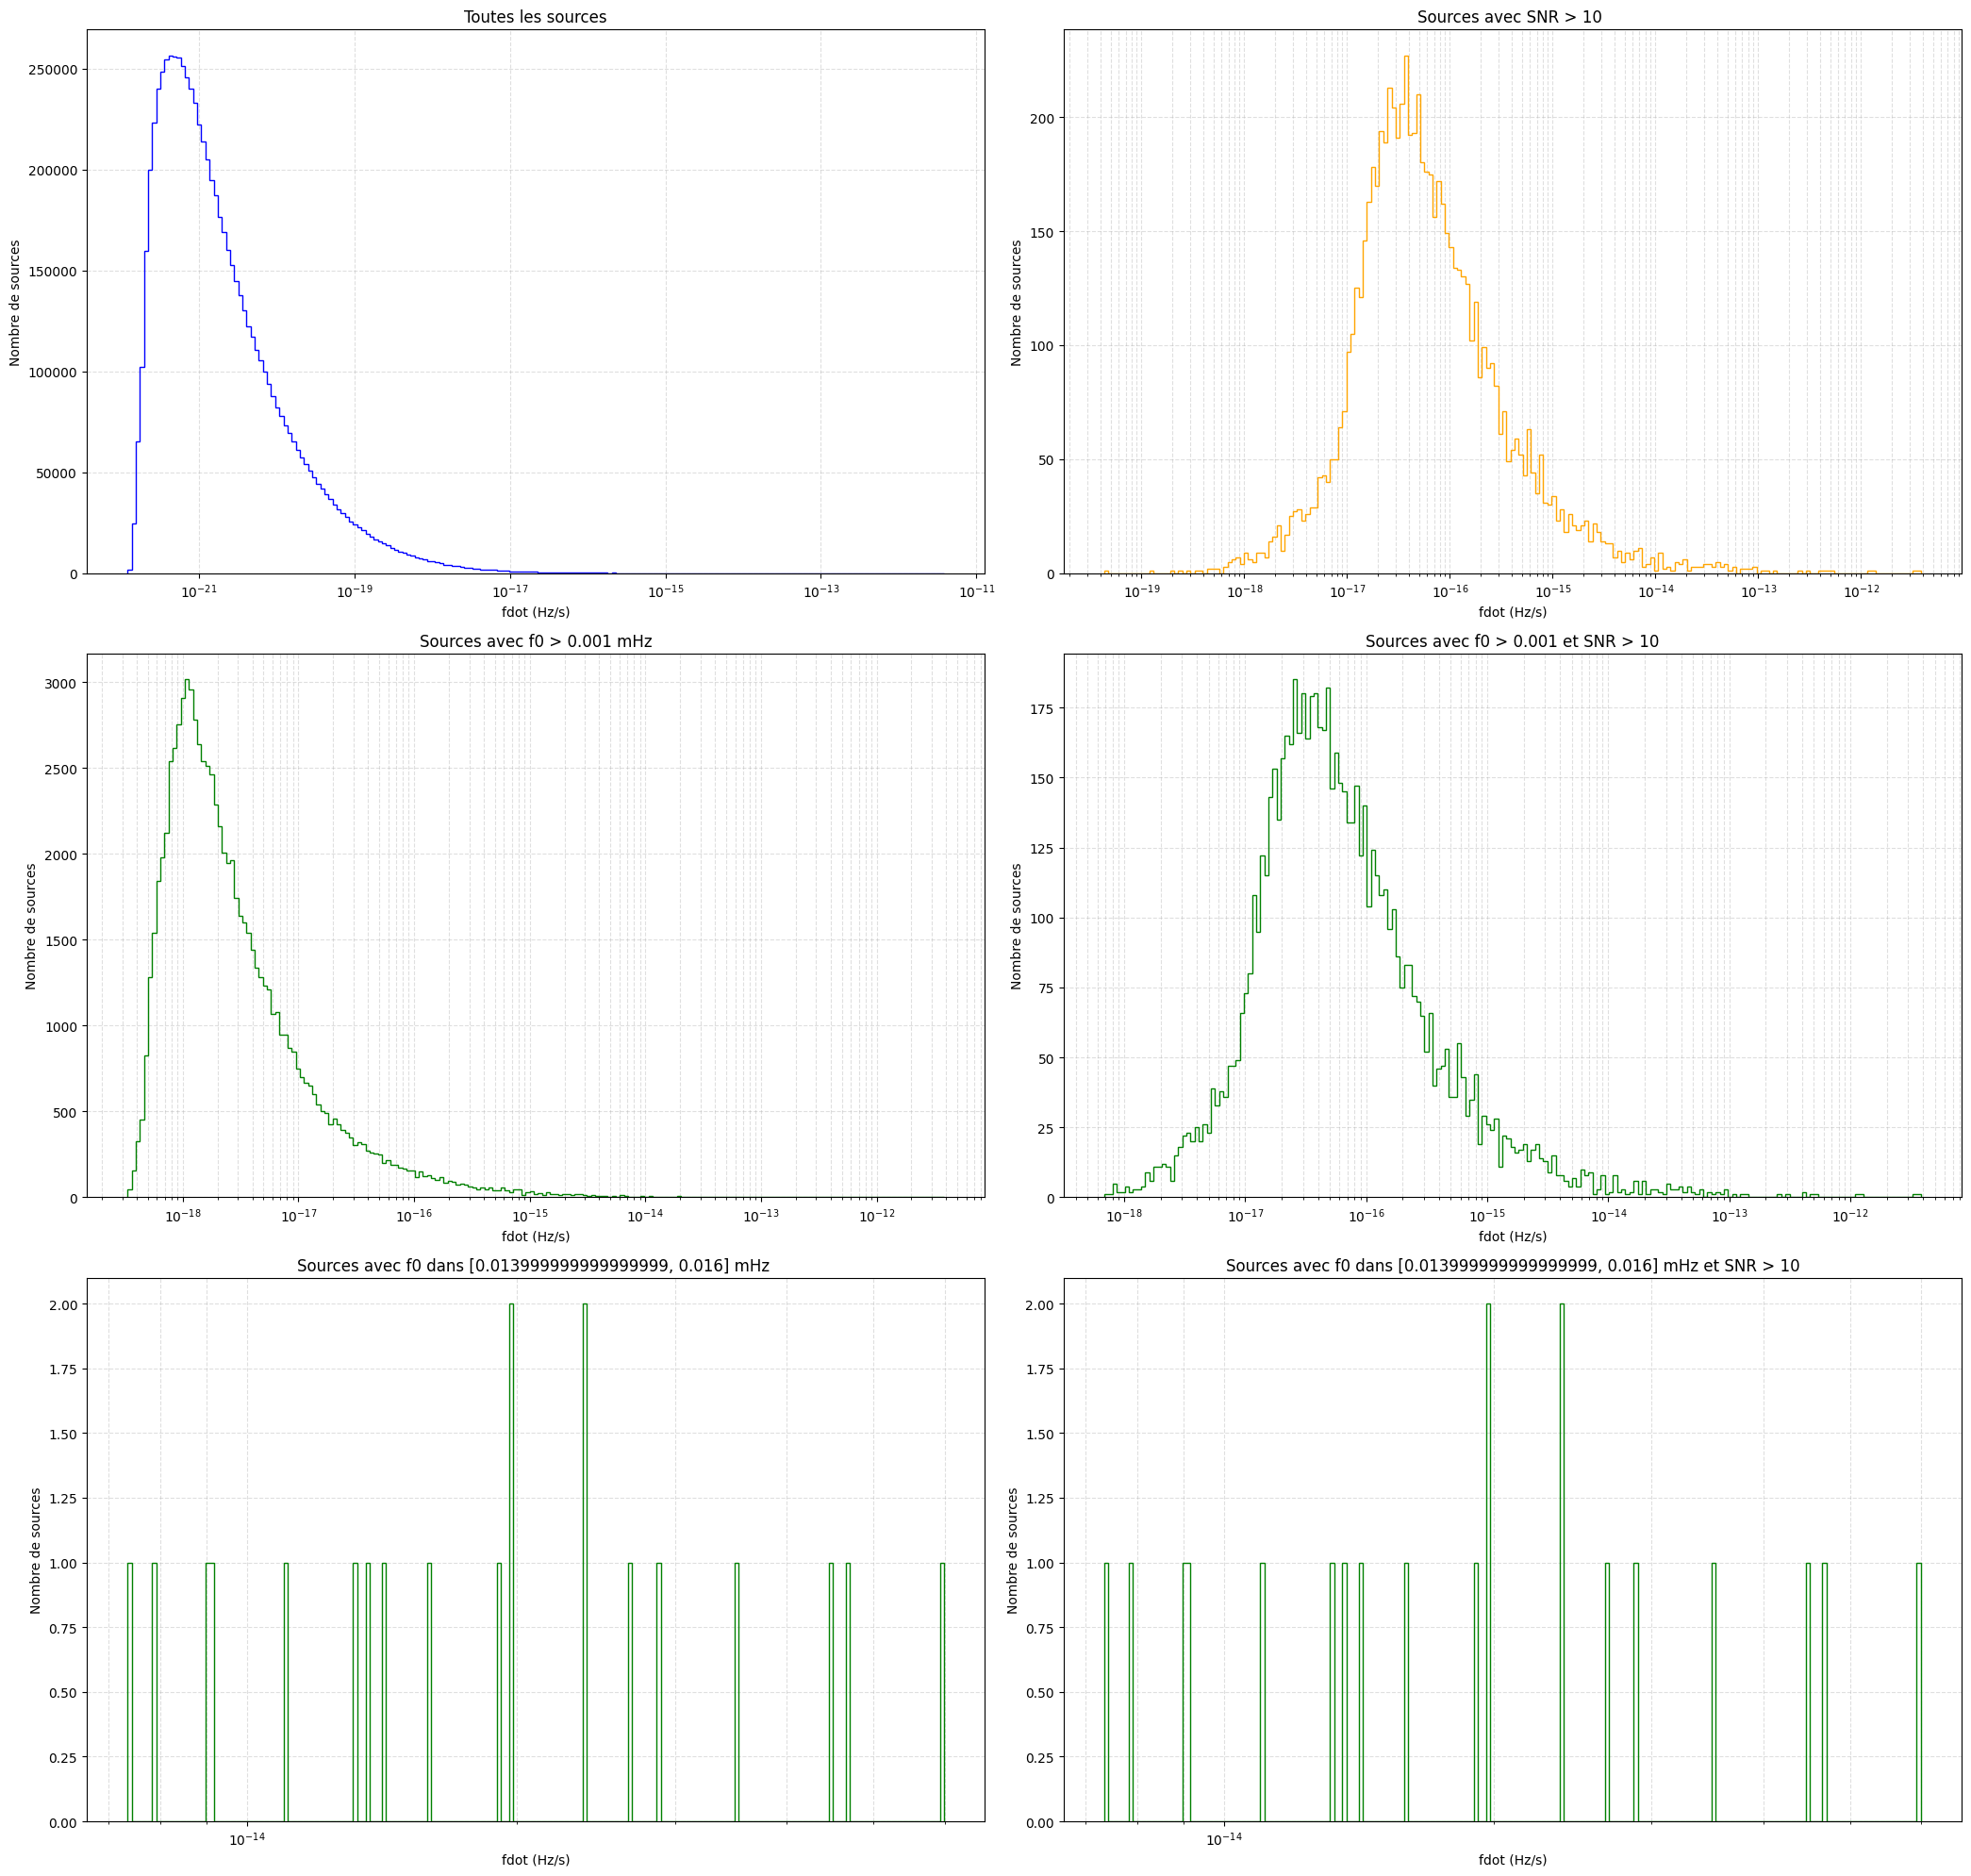

In [16]:

f0_treshold = 1e-3  # 1 mHz
SNR_treshold = 10

center = 15e-3   #f_central     # 4 mHz
window = 1.0e-3 #100*64*df     # ±1 mHz


fdot_f0 = fdot[f0 > f0_treshold]
fdot_center = fdot[(f0 > (center - window)) & (f0 < (center + window))]
fdot_SNR = fdot[SNR > SNR_treshold]
fdot_SNR_f0 = fdot[(f0 > f0_treshold)  & (SNR > SNR_treshold)]
fdot_SNR_center = fdot[(f0 > (center - window)) & (f0 < (center + window))  & (SNR > SNR_treshold)]

bins = np.geomspace(fdot.min(), fdot.max(), 200)
bins_f0 = np.geomspace(fdot_f0.min(), fdot_f0.max(), 200)
bins_center = np.geomspace(fdot_center.min(), fdot_center.max(), 200)
bins_SNR = np.geomspace(fdot_SNR.min(), fdot_SNR.max(), 200)
bins_SNR_f0 = np.geomspace(fdot_SNR_f0.min(), fdot_SNR_f0.max(), 200)
bins_SNR_center = np.geomspace(fdot_SNR_center.min(), fdot_SNR_center.max(), 200)


# Créer la figure avec 3 sous-graphes côte à côte
fig, axes = plt.subplots(3, 2, figsize=(21,20))

axes[0, 0].hist(fdot, bins=bins, histtype='step', color='blue')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel("fdot (Hz/s)")
axes[0, 0].set_ylabel("Nombre de sources")
axes[0, 0].set_title("Toutes les sources")
axes[0, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[0, 1].hist(fdot_SNR, bins=bins_SNR, histtype='step', color='orange')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlabel("fdot (Hz/s)")
axes[0, 1].set_ylabel("Nombre de sources")
axes[0, 1].set_title(f"Sources avec SNR > {SNR_treshold} ")
axes[0, 1].grid(True, which="both", ls="--", alpha=0.4)



axes[1, 0].hist(fdot_f0, bins=bins_f0, histtype='step', color='green')
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel("fdot (Hz/s)")
axes[1, 0].set_ylabel("Nombre de sources")
axes[1, 0].set_title(f"Sources avec f0 > {f0_treshold} mHz")
axes[1, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[1, 1].hist(fdot_SNR_f0, bins=bins_SNR_f0, histtype='step', color='green')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel("fdot (Hz/s)")
axes[1, 1].set_ylabel("Nombre de sources")
axes[1, 1].set_title(f"Sources avec f0 > {f0_treshold} et SNR > {SNR_treshold}")
axes[1, 1].grid(True, which="both", ls="--", alpha=0.4)


axes[2, 0].hist(fdot_center, bins=bins_center, histtype='step', color='green')
axes[2, 0].set_xscale('log')
axes[2, 0].set_xlabel("fdot (Hz/s)")
axes[2, 0].set_ylabel("Nombre de sources")
axes[2, 0].set_title(f"Sources avec f0 dans [{center - window}, {center + window}] mHz ")
axes[2, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[2, 1].hist(fdot_SNR_center, bins=bins_SNR_center, histtype='step', color='green')
axes[2, 1].set_xscale('log')
axes[2, 1].set_xlabel("fdot (Hz/s)")
axes[2, 1].set_ylabel("Nombre de sources")
axes[2, 1].set_title(f"Sources avec f0 dans [{center - window}, {center + window}] mHz et SNR > {SNR_treshold}")
axes[2, 1].grid(True, which="both", ls="--", alpha=0.4)


plt.tight_layout()
plt.show()


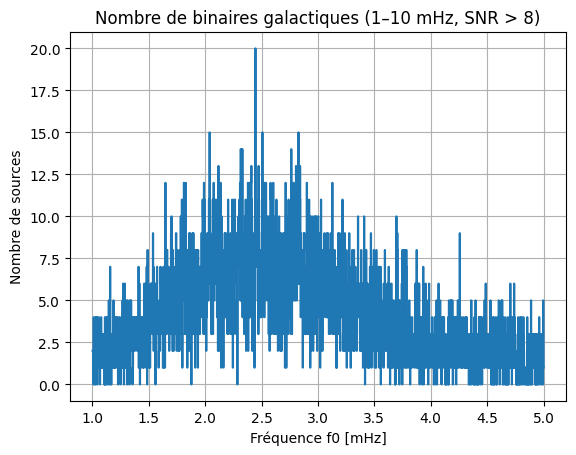

In [17]:

f0min = 1e-3
f0max = 5e-3
mask = (SNR > 8) & (f0 > f0min) & (f0 <= f0max)  # 10 mHz = 1e-2 Hz
f0_sel = f0[mask]

# --- Définition des bins ---
df = 2e-6  # 4 microHz
bins = np.arange(f0_sel.min(), f0_sel.max() + df, df)

# --- Histogramme ---
counts, edges = np.histogram(f0_sel, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

# --- Plot ---
plt.figure()
plt.step(centers * 1e3, counts, where="mid")
plt.xlabel("Fréquence f0 [mHz]")
plt.ylabel("Nombre de sources")
plt.title("Nombre de binaires galactiques (1–10 mHz, SNR > 8)")
plt.grid(True)
plt.show()


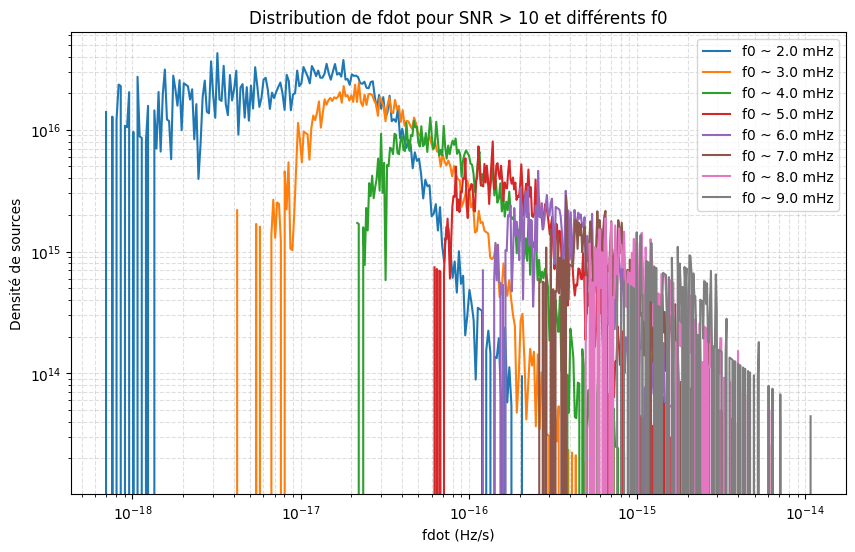

In [18]:
# Paramètres
SNR_threshold = 10
window = 1e-3  # ±1 mHz
centers = np.linspace(2e-3, 9e-3, 8)  # 8 valeurs de center

plt.figure(figsize=(10,6))

for c in centers:
    # Filtrer fdot pour les sources dans le window autour du centre et avec SNR > threshold
    mask = (f0 > (c - window)) & (f0 < (c + window)) & (SNR > SNR_threshold)
    fdot_filtered = fdot[mask]

    if len(fdot_filtered) == 0:
        continue  # éviter les centres sans sources

    # Histogramme normalisé (densité) pour comparer les courbes
    counts, bins = np.histogram(fdot_filtered, bins=np.geomspace(fdot_filtered.min(), fdot_filtered.max(), 200), density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    plt.plot(bin_centers, counts, label=f"f0 ~ {c*1e3:.1f} mHz")

plt.xscale('log')
plt.yscale('log')
plt.xlabel("fdot (Hz/s)")
plt.ylabel("Densité de sources")
plt.title(f"Distribution de fdot pour SNR > {SNR_threshold} et différents f0")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()


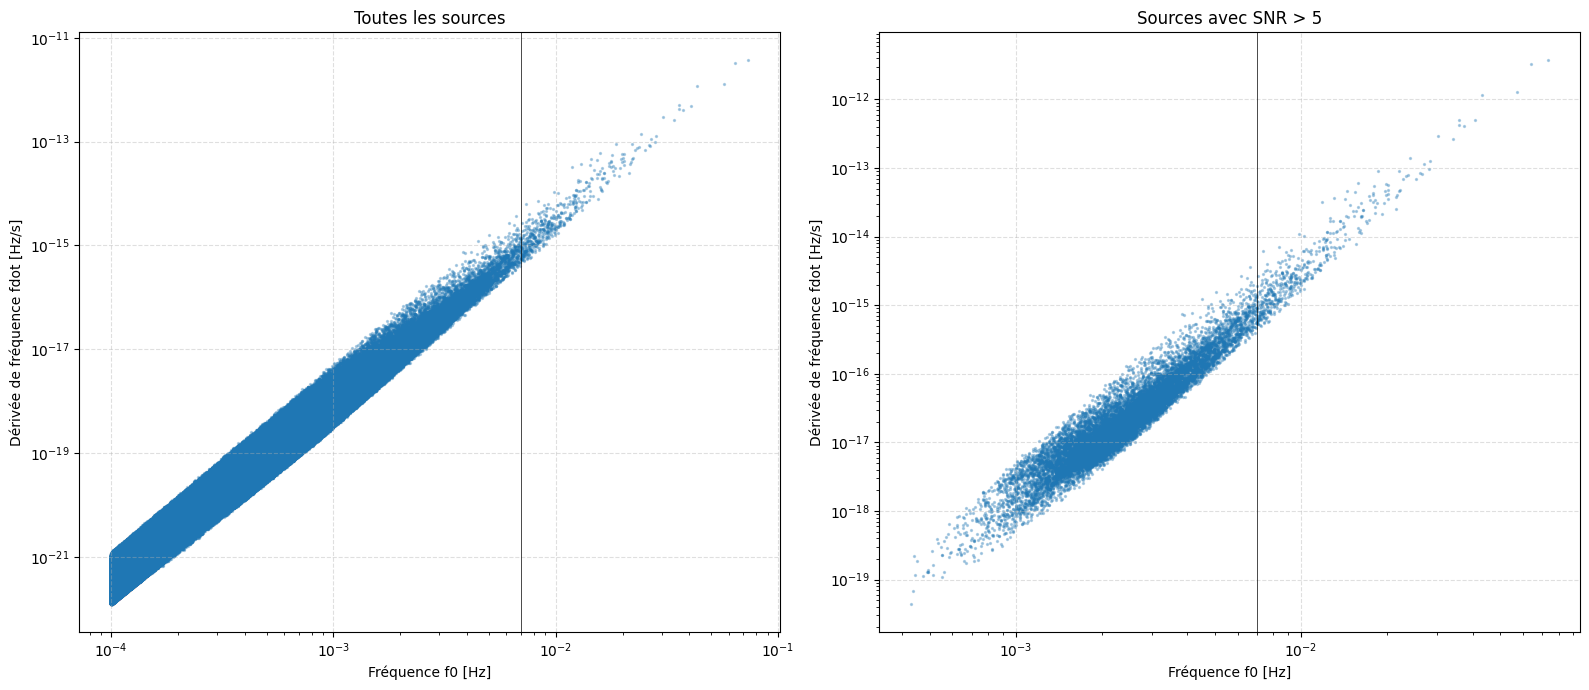

In [19]:
import matplotlib.pyplot as plt

# Masque pour SNR > 5
SNR_treshold = 5
mask = SNR > SNR_treshold
f_central = 7e-3

# Création de la figure avec 2 sous-graphes côte à côte (ou verticalement)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))  # 1 ligne, 2 colonnes

# Premier plot : toutes les sources
axes[0].scatter(f0, fdot, s=2, alpha=0.3)
axes[0].set_xlabel("Fréquence f0 [Hz]")
axes[0].set_ylabel("Dérivée de fréquence fdot [Hz/s]")
axes[0].axvline(f_central, c='k', lw=0.5)
axes[0].set_title("Toutes les sources")
axes[0].grid(True, ls="--", alpha=0.4)
axes[0].set_xscale("log")
axes[0].set_yscale("log")  # symlog pratique si fdot peut être négatif

# Deuxième plot : sources avec SNR > 5
axes[1].scatter(f0[mask], fdot[mask], s=2, alpha=0.3)
axes[1].set_xlabel("Fréquence f0 [Hz]")
axes[1].set_ylabel("Dérivée de fréquence fdot [Hz/s]")
axes[1].axvline(f_central, c='k', lw=0.5)
axes[1].set_title(f"Sources avec SNR > {SNR_treshold}")
axes[1].grid(True, ls="--", alpha=0.4)
axes[1].set_xscale("log")
axes[1].set_yscale("log")  # symlog pratique si fdot peut être négatif

plt.tight_layout()  # Ajuste l'espacement automatiquement
plt.show()


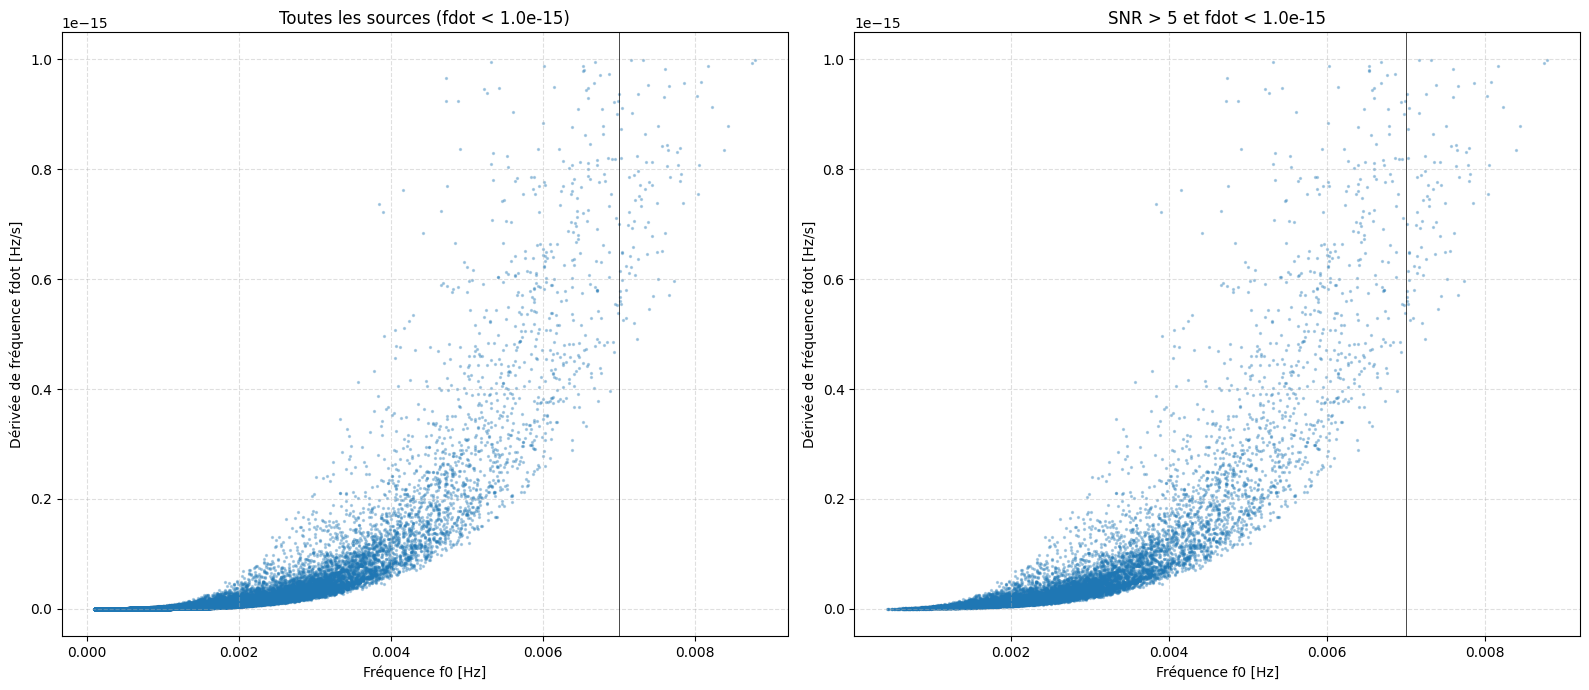

In [20]:
import matplotlib.pyplot as plt

# Seuils
SNR_treshold = 5
fdot_threshold = 1e-15   # <<< À ajuster selon tes besoins

# Masques
mask_SNR = SNR > SNR_treshold
mask_fdot = fdot < fdot_threshold
mask_both = mask_SNR & mask_fdot

# Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Premier plot : toutes les sources mais fdot filtré ---
axes[0].scatter(f0[mask_fdot], fdot[mask_fdot], s=2, alpha=0.3)
axes[0].set_xlabel("Fréquence f0 [Hz]")
axes[0].set_ylabel("Dérivée de fréquence fdot [Hz/s]")
axes[0].axvline(f_central, c='k', lw=0.5)
axes[0].set_title(f"Toutes les sources (fdot < {fdot_threshold:.1e})")
axes[0].grid(True, ls="--", alpha=0.4)
# axes[0].set_xscale("log")
# axes[0].set_yscale("log")

# --- Deuxième plot : SNR > 5 et fdot < threshold ---
axes[1].scatter(f0[mask_both], fdot[mask_both], s=2, alpha=0.3)
axes[1].set_xlabel("Fréquence f0 [Hz]")
axes[1].set_ylabel("Dérivée de fréquence fdot [Hz/s]")
axes[1].axvline(f_central, c='k', lw=0.5)
axes[1].set_title(f"SNR > {SNR_treshold} et fdot < {fdot_threshold:.1e}")
axes[1].grid(True, ls="--", alpha=0.4)
# axes[1].set_xscale("log")
# axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


In [21]:
import numpy as np

# Fréquence en Hz
f_min = 3.9e-3  # 3 mHz
f_max = 4.1e-3  # 5 mHz

# Masque pour filtrer les sources dans l'intervalle de fréquence
mask_f = (f0 >= f_min) & (f0 <= f_max)

# fdot des sources filtrées
fdot_filtered = fdot[mask_f]

# Calcul du minimum et maximum
fdot_min = np.min(fdot_filtered)
fdot_max = np.max(fdot_filtered)

print(f"Pour {len(fdot_filtered)} sources avec f0 entre {f_min} Hz et {f_max} Hz :")
print(f"fdot min = {fdot_min:.3e} Hz/s")
print(f"fdot max = {fdot_max:.3e} Hz/s")


Pour 267 sources avec f0 entre 0.0039 Hz et 0.0041 Hz :
fdot min = 4.592e-17 Hz/s
fdot max = 5.076e-16 Hz/s


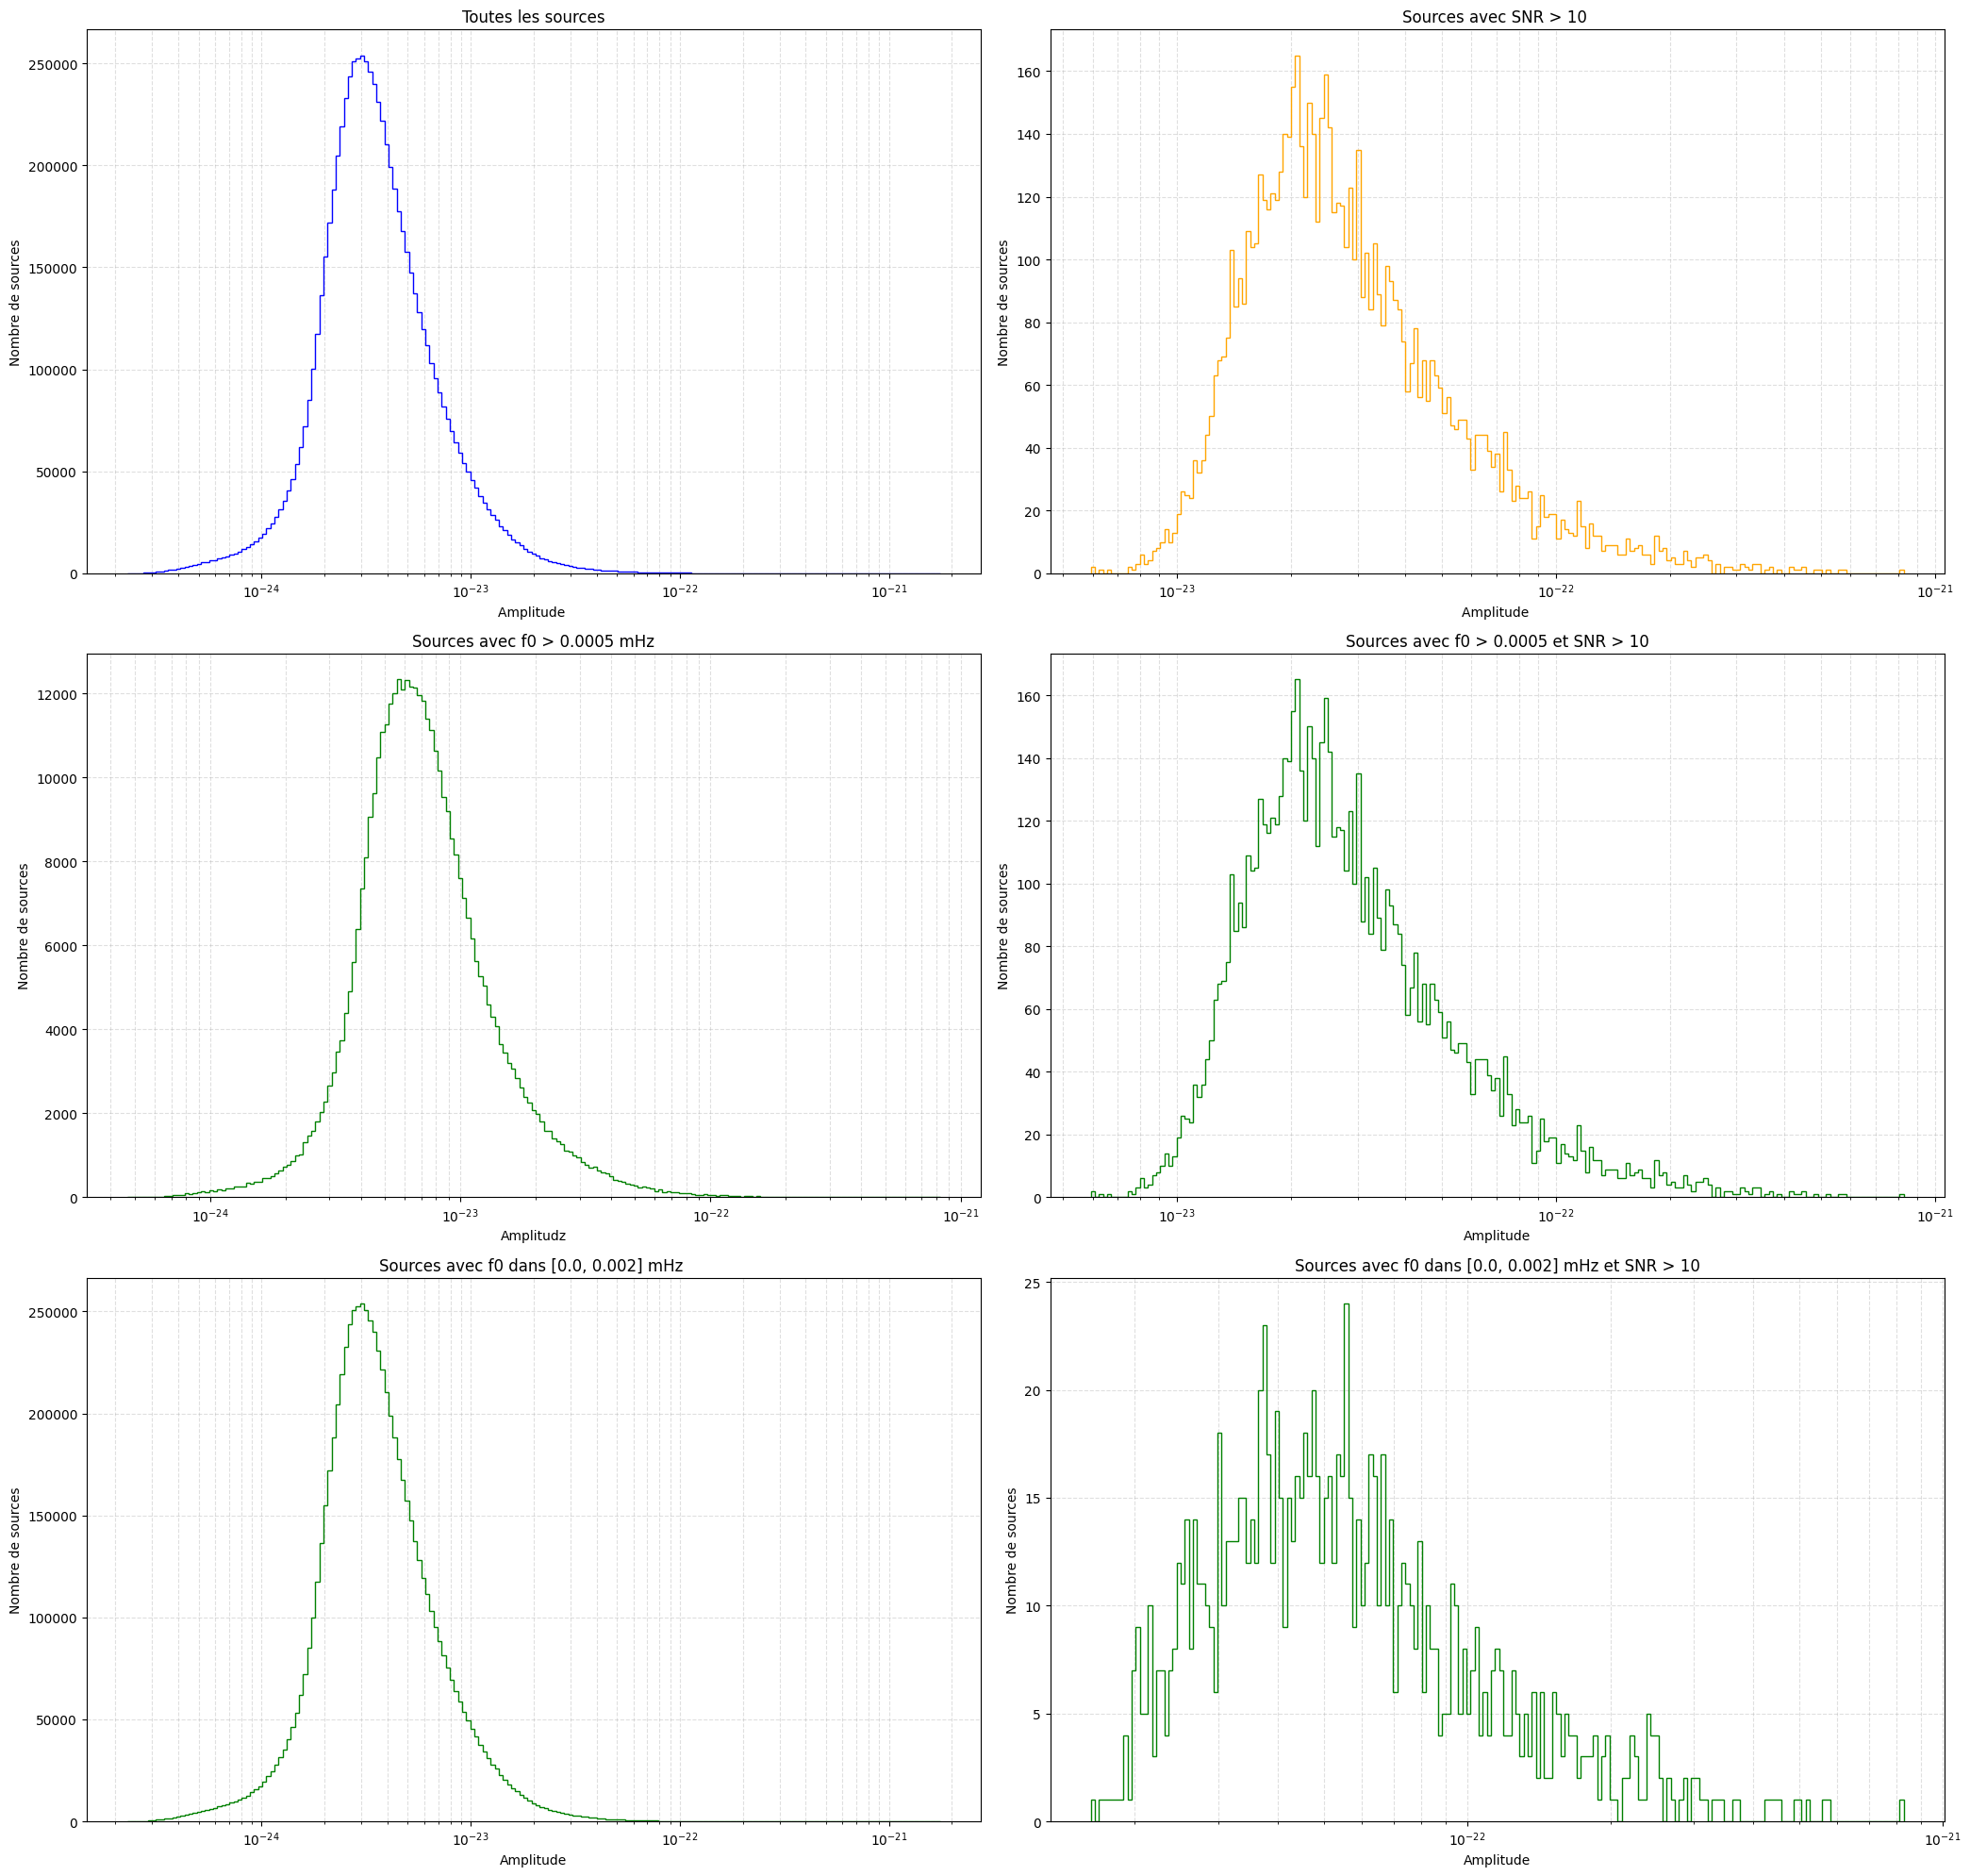

1.6171628671301057e-23
8.275617799400581e-22


In [42]:

f0_treshold = 0.5e-3  # 1 mHz
SNR_treshold = 10

center = 0.001 #4e-3       # 4 mHz
window = 1e-3      # ±1 mHz

amp_f0 = amp[f0 > f0_treshold]
amp_center = amp[(f0 > (center - window)) & (f0 < (center + window))]
amp_SNR = amp[SNR > SNR_treshold]
amp_SNR_f0 = amp[(f0 > f0_treshold)  & (SNR > SNR_treshold)]
amp_SNR_center = amp[(f0 > (center - window)) & (f0 < (center + window))  & (SNR > SNR_treshold)]

bins = np.geomspace(amp.min(), amp.max(), 200)
bins_f0 = np.geomspace(amp_f0.min(), amp_f0.max(), 200)
bins_center = np.geomspace(amp_center.min(), amp_center.max(), 200)
bins_SNR = np.geomspace(amp_SNR.min(), amp_SNR.max(), 200)
bins_SNR_f0 = np.geomspace(amp_SNR_f0.min(), amp_SNR_f0.max(), 200)
bins_SNR_center = np.geomspace(amp_SNR_center.min(), amp_SNR_center.max(), 200)


# Créer la figure avec 3 sous-graphes côte à côte
fig, axes = plt.subplots(3, 2, figsize=(21,20))

axes[0, 0].hist(amp, bins=bins, histtype='step', color='blue')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel("Amplitude ")
axes[0, 0].set_ylabel("Nombre de sources")
axes[0, 0].set_title("Toutes les sources")
axes[0, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[0, 1].hist(amp_SNR, bins=bins_SNR, histtype='step', color='orange')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlabel("Amplitude ")
axes[0, 1].set_ylabel("Nombre de sources")
axes[0, 1].set_title(f"Sources avec SNR > {SNR_treshold} ")
axes[0, 1].grid(True, which="both", ls="--", alpha=0.4)



axes[1, 0].hist(amp_f0, bins=bins_f0, histtype='step', color='green')
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel("Amplitudz")
axes[1, 0].set_ylabel("Nombre de sources")
axes[1, 0].set_title(f"Sources avec f0 > {f0_treshold} mHz")
axes[1, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[1, 1].hist(amp_SNR_f0, bins=bins_SNR_f0, histtype='step', color='green')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel("Amplitude")
axes[1, 1].set_ylabel("Nombre de sources")
axes[1, 1].set_title(f"Sources avec f0 > {f0_treshold} et SNR > {SNR_treshold}")
axes[1, 1].grid(True, which="both", ls="--", alpha=0.4)

axes[2, 0].hist(amp_center, bins=bins_center, histtype='step', color='green')
axes[2, 0].set_xscale('log')
axes[2, 0].set_xlabel("Amplitude")
axes[2, 0].set_ylabel("Nombre de sources")
axes[2, 0].set_title(f"Sources avec f0 dans [{center - window}, {center + window}] mHz ")
axes[2, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[2, 1].hist(amp_SNR_center, bins=bins_SNR_center, histtype='step', color='green')
axes[2, 1].set_xscale('log')
axes[2, 1].set_xlabel("Amplitude")
axes[2, 1].set_ylabel("Nombre de sources")
axes[2, 1].set_title(f"Sources avec f0 dans [{center - window}, {center + window}] mHz et SNR > {SNR_treshold}")
axes[2, 1].grid(True, which="both", ls="--", alpha=0.4)


plt.tight_layout()
plt.show()



print(min(amp_SNR_center))
print(max(amp_SNR_center))

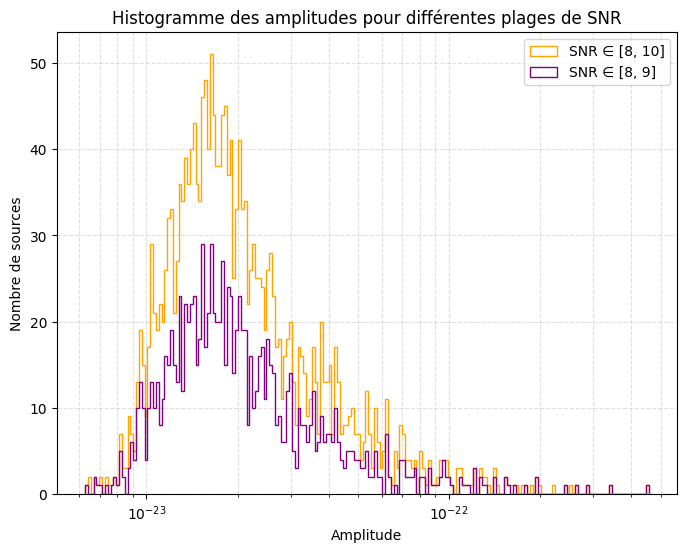

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Seuils
SNR_min1, SNR_max1 = 8, 9
SNR_min2, SNR_max2 = 8, 10

# Filtrer les amplitudes
amp_SNR_range1 = amp[(SNR >= SNR_min1) & (SNR <= SNR_max1)]
amp_SNR_range2 = amp[(SNR >= SNR_min2) & (SNR <= SNR_max2)]

# Définir des bins communs (logarithmiques)
bins = np.geomspace(min(amp_SNR_range1.min(), amp_SNR_range2.min()), 
                    max(amp_SNR_range1.max(), amp_SNR_range2.max()), 200)

# Tracé
plt.figure(figsize=(8,6))
plt.hist(amp_SNR_range2, bins=bins, histtype='step', color='orange', lw=2, label=f"SNR ∈ [{SNR_min2}, {SNR_max2}]")
plt.hist(amp_SNR_range1, bins=bins, histtype='step', color='purple', lw=2, label=f"SNR ∈ [{SNR_min1}, {SNR_max1}]")

plt.xscale('log')
plt.xlabel("Amplitude")
plt.ylabel("Nombre de sources")
plt.title("Histogramme des amplitudes pour différentes plages de SNR")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()

In [24]:
import numpy as np

# --- Choisis la plage SNR que tu veux analyser ---
SNR_min, SNR_max = 8, 10

# Masque de sélection
mask = (SNR >= SNR_min) & (SNR <= SNR_max)

# Indices des sources dans cette plage
indices = np.where(mask)[0]

# Amplitudes correspondantes
amp_filtered = amp[indices]

# Indice local du max
local_max_index = np.argmax(amp_filtered)

# Indice global dans le catalogue
global_index = indices[local_max_index]

# --- Extraction des paramètres ---
result = {
    "f0": f0[global_index],
    "fdot": fdot[global_index],
    "beta": beta[global_index],
    "lambda": lam[global_index],
    "amplitude": amp[global_index],
    "iota": iota[global_index],
    "phi0": phi0[global_index],
    "psi": psi[global_index],
    "SNR": SNR[global_index]
}

# Affichage
for key, value in result.items():
    print(f"{key} : {value}")

f0 : 0.0004389364621601999
fdot : 2.1829383497858265e-19
beta : -0.46023717544243137
lambda : 5.227501466903823
amplitude : 4.5693875155299855e-22
iota : 0.8317270712748168
phi0 : -0.04747457944037459
psi : -0.3777428312228497
SNR : 8.072217524425852


Nombre de sources dans la plage : 102


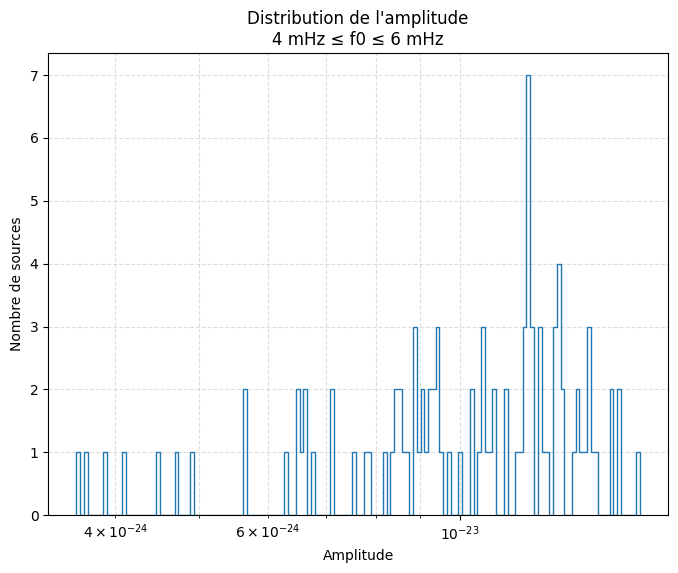

Nombre dans l'intervalle : 56
Proportion : 0.5490196078431373
Pourcentage : 54.90196078431373 %


In [25]:
import numpy as np
import matplotlib.pyplot as plt


mask = (
    (f0 >= 4e-3) & (f0 <= 6e-3) &
    (SNR >= 5) & (SNR <= 10)
)

# Amplitudes correspondantes
amp_selected = amp[mask]

print("Nombre de sources dans la plage :", len(amp_selected))

# Bins logarithmiques
bins = np.geomspace(amp_selected.min(), amp_selected.max(), 150)

# Histogramme
plt.figure(figsize=(8,6))
plt.hist(amp_selected, bins=bins, histtype='step', lw=2)

plt.xscale('log')
plt.xlabel("Amplitude")
plt.ylabel("Nombre de sources")
plt.title("Distribution de l'amplitude\n4 mHz ≤ f0 ≤ 6 mHz")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

# Intervalle d'amplitude
lower = 1e-23
upper = 5e-23

# Nombre dans l'intervalle
count_interval = np.sum((amp_selected >= lower) & (amp_selected <= upper))

# Proportion
proportion = count_interval / len(amp_selected)

print("Nombre dans l'intervalle :", count_interval)
print("Proportion :", proportion)
print("Pourcentage :", proportion * 100, "%")

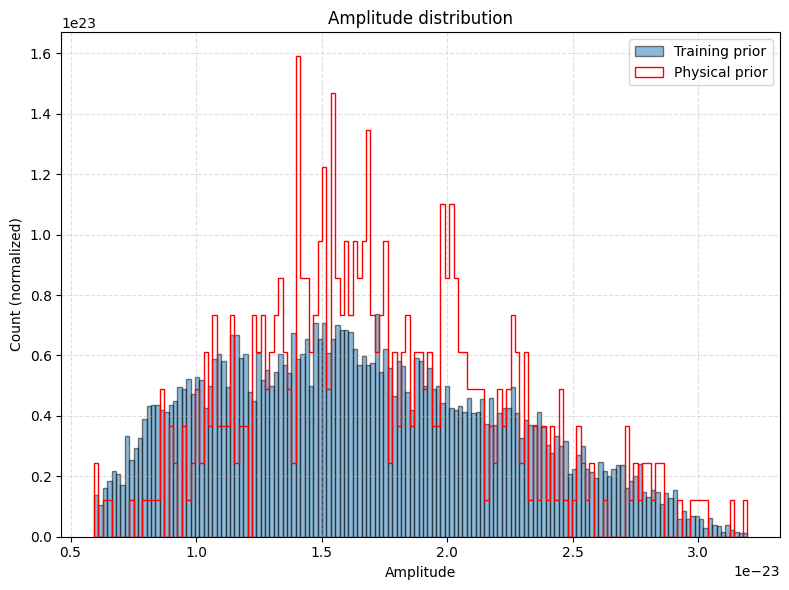

In [26]:
import numpy as np
import matplotlib.pyplot as plt
def reconstruct_params(a1, a2, a3, a4):

    A = a1**2 + a2**2 + a3**2 + a4**2
    D = a1*a4 - a2*a3

    Ap = 0.5*(np.sqrt(A + 2.0*D) + np.sqrt(A - 2.0*D))
    Ac = 0.5*(np.sqrt(A - 2.0*D) - np.sqrt(A + 2.0*D))

    Amp = 0.5*(Ap + np.sqrt(Ap*Ap - Ac*Ac))
    cosinc = 0.5*Ac/Amp
    phi0 = -0.5*np.arctan2(2.0*(a1*a3 + a2*a4), (a1*a1 + a2*a2 - a3*a3 - a4*a4))
    psi = 0.25*np.arctan2(2.0*(a1*a2 + a3*a4), (a1*a1 + a3*a3 - a2*a2 - a4*a4))

    psi[psi < 0.] += 2*np.pi
    phi0[phi0 < 0.] += 2*np.pi

    return Amp, cosinc, phi0, psi 

a1 = np.loadtxt("a1.txt")
a2 = np.loadtxt("a2.txt")
a3 = np.loadtxt("a3.txt")
a4 = np.loadtxt("a4.txt")

AMP, cos_iota, phi, psi = reconstruct_params(a1, a2, a3, a4)
# Exemple de masquage
mask = (
    (f0 >= 4e-3) & (f0 <= 6e-3) &
    (SNR >= 10) & (SNR <= 20)
)
amp_selected = amp[mask]

# Bins pour l'histogramme (logarithmique si amplitudes très petites)
bins = np.linspace(amp_selected.min(), amp_selected.max(), 150)  # 150 bins linéaires
plt.figure(figsize=(8,6))

# Histogramme pour toutes les sources
plt.hist(AMP, bins=bins, color="#1f77b4",density=True, edgecolor="black", alpha=0.5, label="Training prior", lw=1)

# Histogramme pour les sources filtrées (step pour style ligne)
plt.hist(amp_selected, bins=bins, histtype='step',density=True, color='red', lw=2, label="Physical prior")

# plt.xscale('log')
# plt.yscale('log')  
plt.xlabel("Amplitude")
plt.ylabel("Count (normalized)")
plt.title("Amplitude distribution")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

Nombre de sources dans la plage : 1385


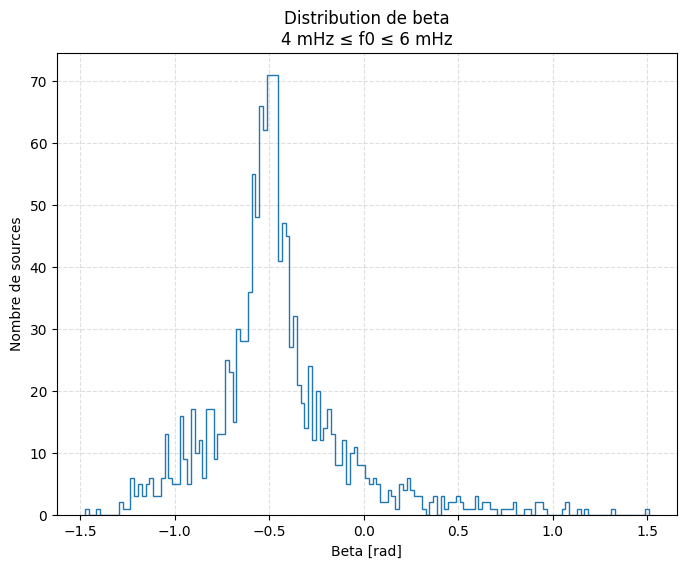

In [27]:
import numpy as np
import matplotlib.pyplot as plt


mask = (
    (f0 >= 4e-3) & (f0 <= 6e-3) &
    (SNR >= 5) & (SNR <= 100)
)

# Amplitudes correspondantes
beta_selected = beta[mask]

print("Nombre de sources dans la plage :", len(beta_selected))

# Bins logarithmiques
# bins = np.geomspace(beta_selected.min(), beta_selected.max(), 150)
bins = np.linspace(beta_selected.min(), beta_selected.max(), 150)

# Histogramme
plt.figure(figsize=(8,6))
plt.hist(beta_selected, bins=bins, histtype='step', lw=2)

# plt.xscale('log')
plt.xlabel("Beta [rad]")
plt.ylabel("Nombre de sources")
plt.title("Distribution de beta\n4 mHz ≤ f0 ≤ 6 mHz")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

Nombre de sources dans la plage : 1385


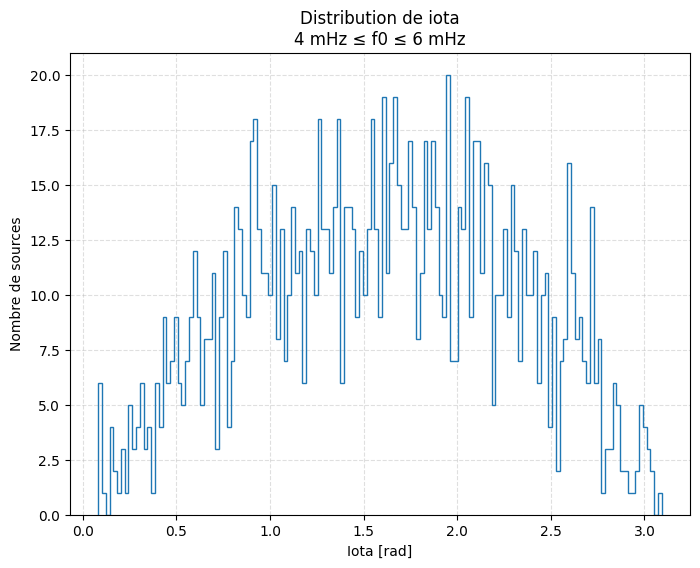

In [28]:
import numpy as np
import matplotlib.pyplot as plt


mask = (
    (f0 >= 4e-3) & (f0 <= 6e-3) &
    (SNR >= 5) & (SNR <= 100)
)

# Amplitudes correspondantes
iota_selected = iota[mask]

print("Nombre de sources dans la plage :", len(iota_selected))

# Bins logarithmiques
# bins = np.geomspace(iota_selected.min(), iota_selected.max(), 150)
bins = np.linspace(iota_selected.min(), iota_selected.max(), 150)

# Histogramme
plt.figure(figsize=(8,6))
plt.hist(iota_selected, bins=bins, histtype='step', lw=2)

# plt.xscale('log')
plt.xlabel("Iota [rad]")
plt.ylabel("Nombre de sources")
plt.title("Distribution de iota\n4 mHz ≤ f0 ≤ 6 mHz")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()

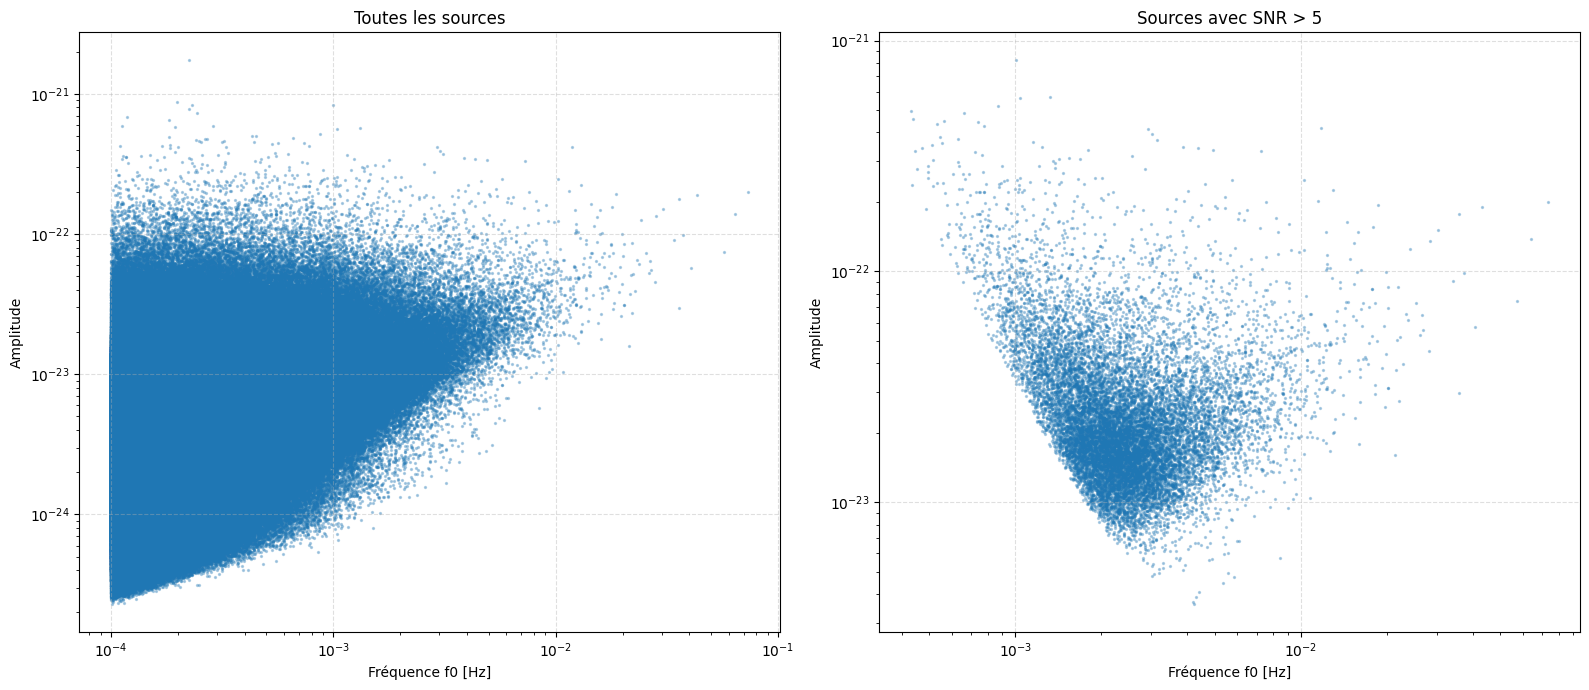

In [29]:

# Masque pour SNR > 5
SNR_treshold = 5
mask = SNR > SNR_treshold

# Création de la figure avec 2 sous-graphes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 7))  # 1 ligne, 2 colonnes

# Premier plot : toutes les sources
axes[0].scatter(f0, amp, s=2, alpha=0.3)
axes[0].set_xlabel("Fréquence f0 [Hz]")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Toutes les sources")
axes[0].grid(True, ls="--", alpha=0.4)
axes[0].set_xscale("log")
axes[0].set_yscale("log")  # amplitude toujours positive

# Deuxième plot : sources avec SNR > 5
axes[1].scatter(f0[mask], amp[mask], s=2, alpha=0.3)
axes[1].set_xlabel("Fréquence f0 [Hz]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title(f"Sources avec SNR > {SNR_treshold}")
axes[1].grid(True, ls="--", alpha=0.4)
axes[1].set_xscale("log")
axes[1].set_yscale("log")  # amplitude toujours positive

plt.tight_layout()  # Ajuste l'espacement
plt.show()


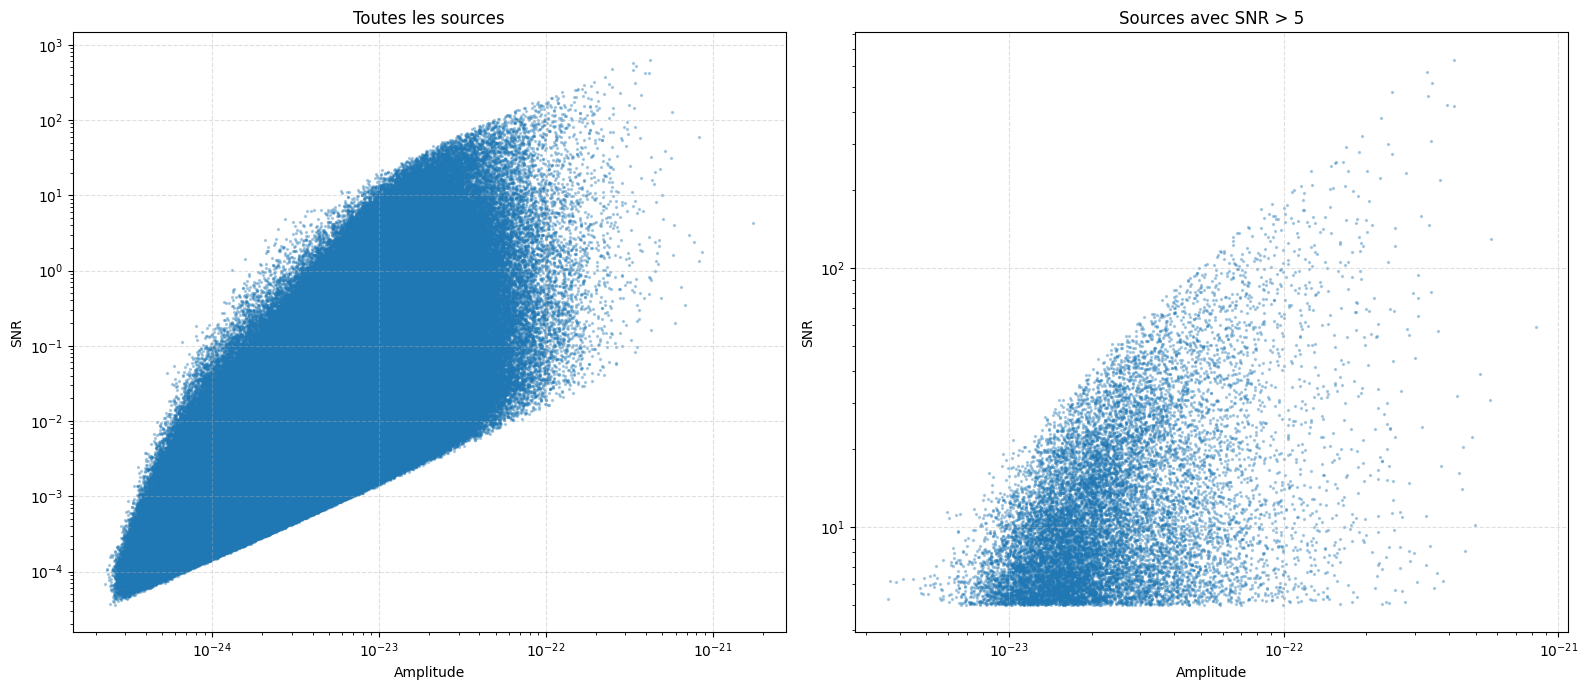

In [30]:

# Masque pour SNR > 5
mask = SNR > 5

# Création de la figure avec 2 sous-graphes côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 7))  # 1 ligne, 2 colonnes

# Premier plot : toutes les sources
axes[0].scatter(amp, SNR, s=2, alpha=0.3)
axes[0].set_xlabel("Amplitude")
axes[0].set_ylabel("SNR")
axes[0].set_title("Toutes les sources")
axes[0].grid(True, ls="--", alpha=0.4)
axes[0].set_xscale("log")
axes[0].set_yscale("log")  # SNR toujours positif

# Deuxième plot : sources avec SNR > 5
axes[1].scatter(amp[mask], SNR[mask], s=2, alpha=0.3)
axes[1].set_xlabel("Amplitude")
axes[1].set_ylabel("SNR")
axes[1].set_title("Sources avec SNR > 5")
axes[1].grid(True, ls="--", alpha=0.4)
axes[1].set_xscale("log")
axes[1].set_yscale("log")  # SNR toujours positif

plt.tight_layout()  # Ajuste l'espacement
plt.show()


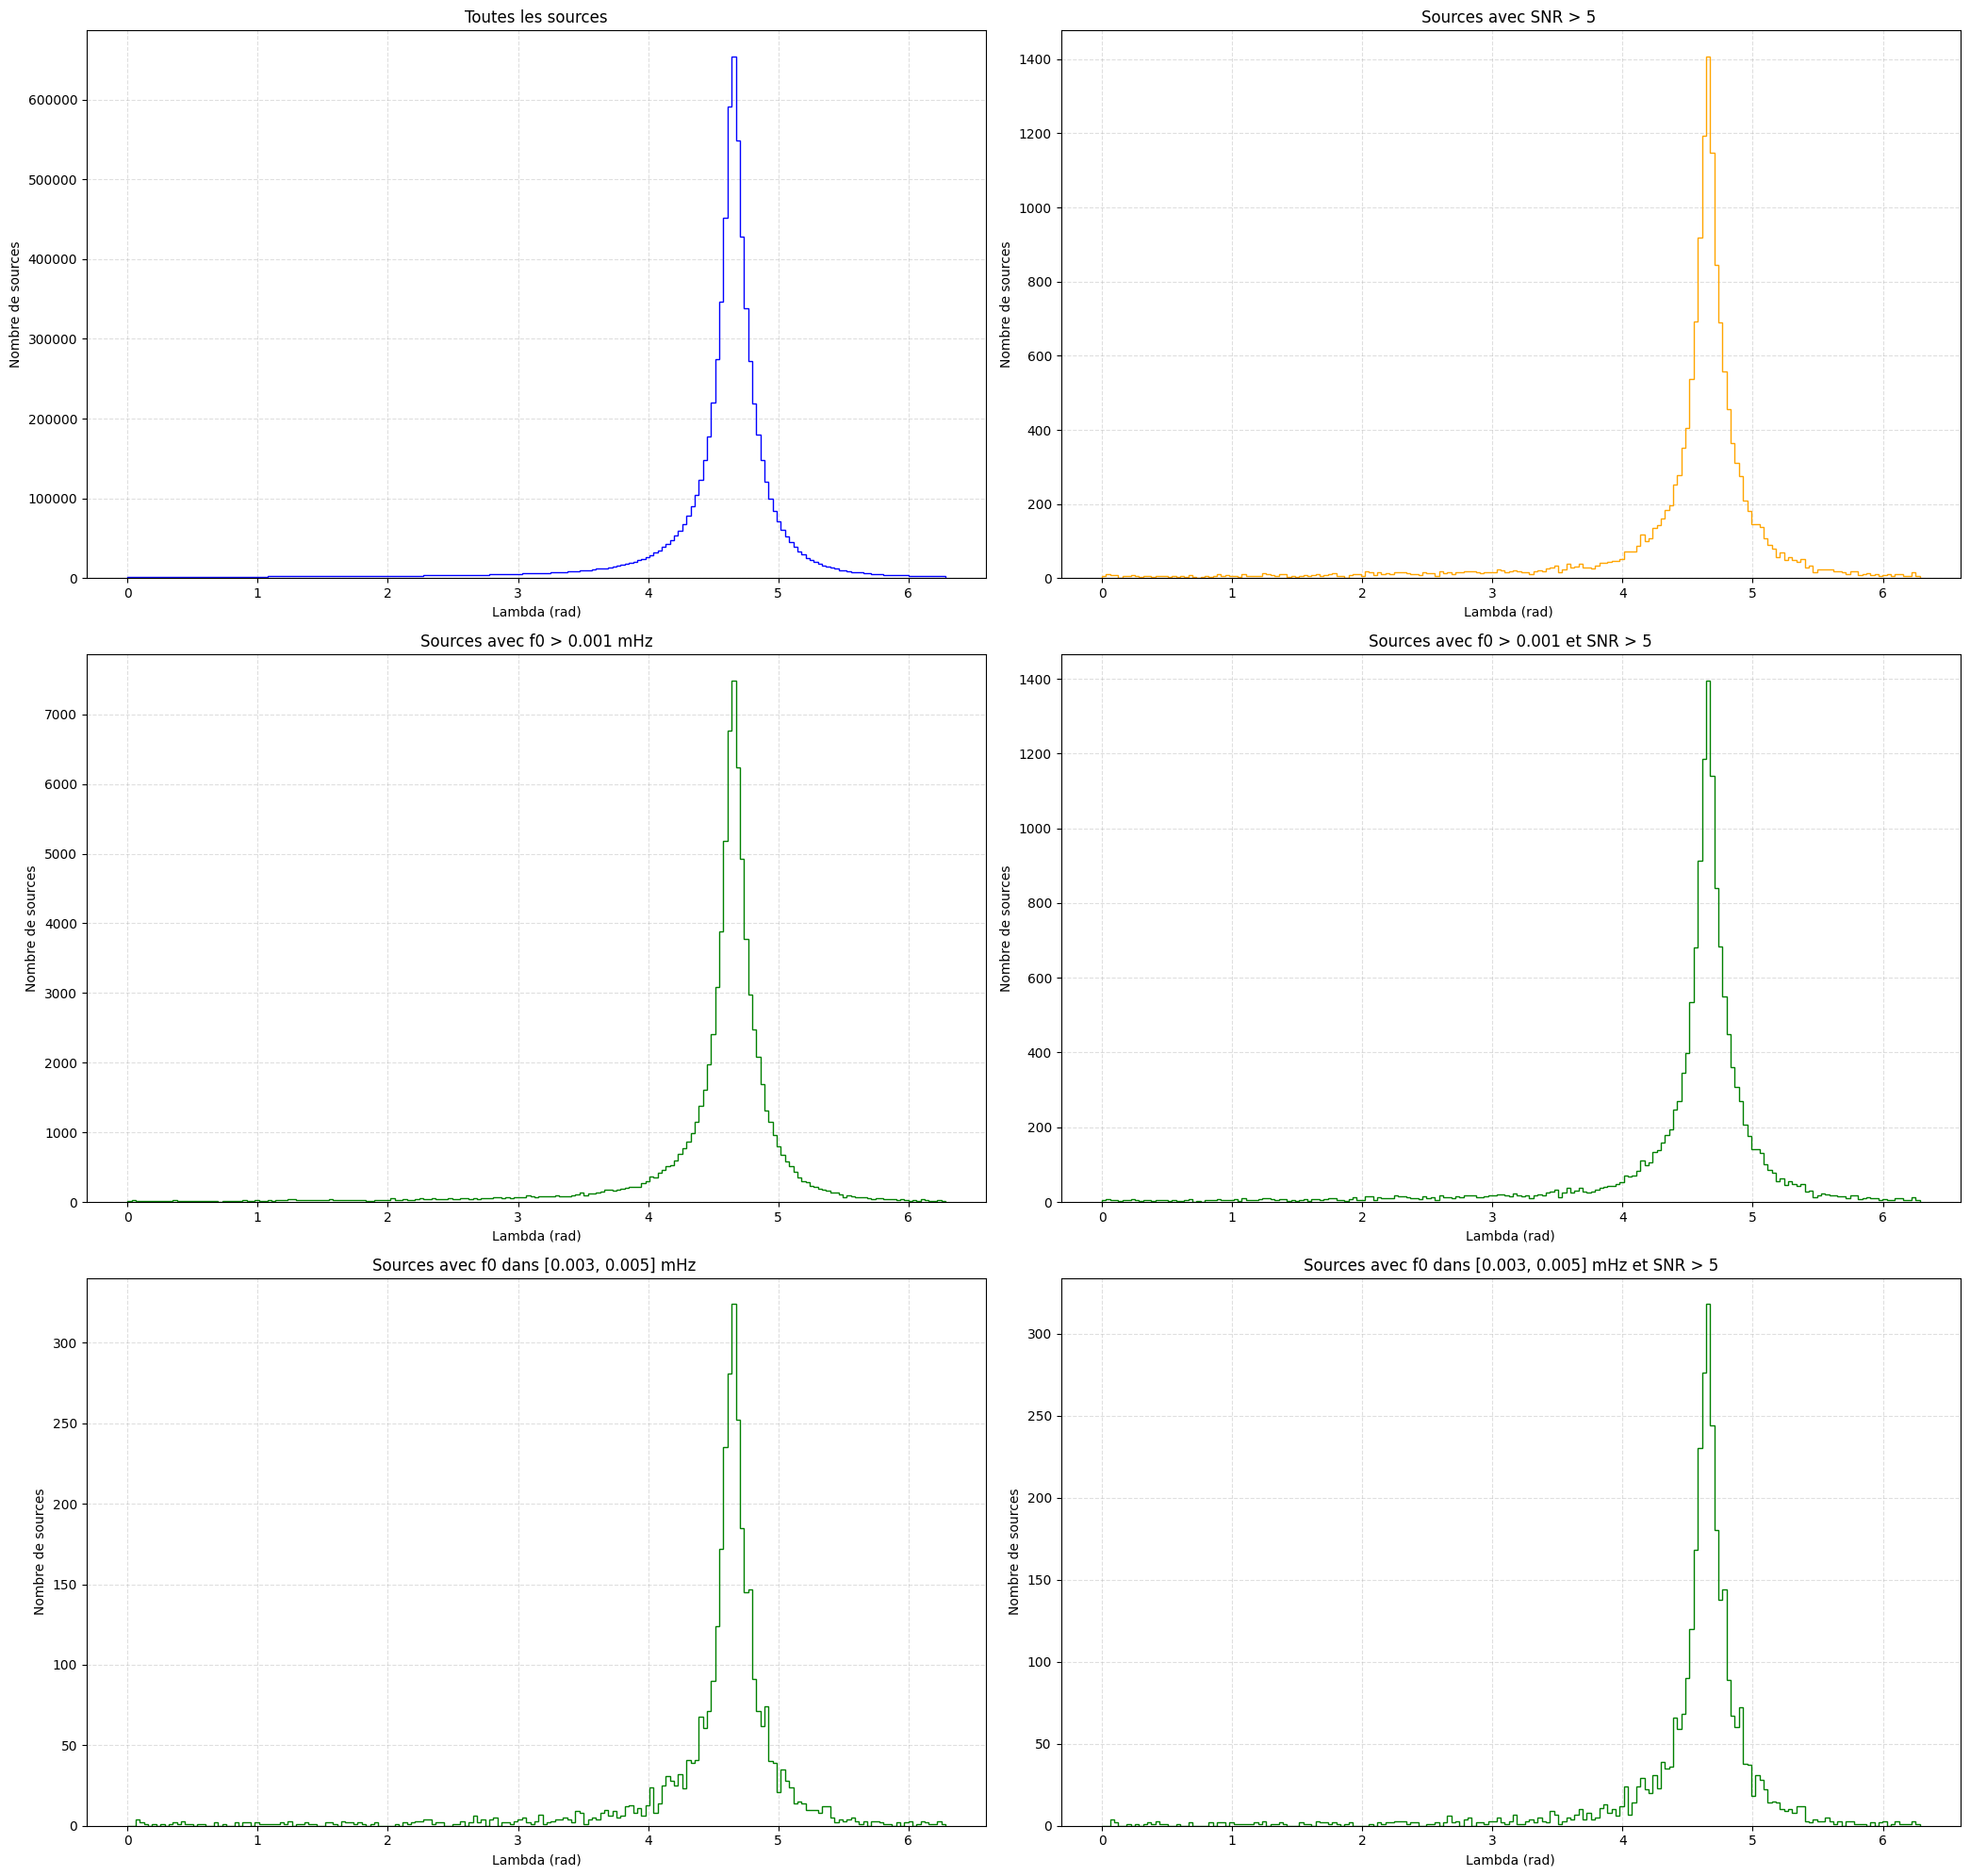

In [31]:

f0_treshold = 1e-3  # 1 mHz
SNR_treshold = 5

center = 4e-3       # 4 mHz
window = 1e-3       # ±1 mHz

lam_f0 = lam[f0 > f0_treshold]
lam_center = lam[(f0 > (center - window)) & (f0 < (center + window))]
lam_SNR = lam[SNR > SNR_treshold]
lam_SNR_f0 = lam[(f0 > f0_treshold)  & (SNR > SNR_treshold)]
lam_SNR_center = lam[(f0 > (center - window)) & (f0 < (center + window))  & (SNR > SNR_treshold)]

bins = np.linspace(lam.min(), lam.max(), 200)


# Créer la figure avec 3 sous-graphes côte à côte
fig, axes = plt.subplots(3, 2, figsize=(21,20))

axes[0, 0].hist(lam, bins=bins, histtype='step', color='blue')
axes[0, 0].set_xlabel("Lambda (rad)")
axes[0, 0].set_ylabel("Nombre de sources")
axes[0, 0].set_title("Toutes les sources")
axes[0, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[0, 1].hist(lam_SNR, bins=bins, histtype='step', color='orange')
axes[0, 1].set_xlabel("Lambda (rad) ")
axes[0, 1].set_ylabel("Nombre de sources")
axes[0, 1].set_title(f"Sources avec SNR > {SNR_treshold} ")
axes[0, 1].grid(True, which="both", ls="--", alpha=0.4)



axes[1, 0].hist(lam_f0, bins=bins, histtype='step', color='green')
axes[1, 0].set_xlabel("Lambda (rad)")
axes[1, 0].set_ylabel("Nombre de sources")
axes[1, 0].set_title(f"Sources avec f0 > {f0_treshold} mHz")
axes[1, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[1, 1].hist(lam_SNR_f0, bins=bins, histtype='step', color='green')
axes[1, 1].set_xlabel("Lambda (rad)")
axes[1, 1].set_ylabel("Nombre de sources")
axes[1, 1].set_title(f"Sources avec f0 > {f0_treshold} et SNR > {SNR_treshold}")
axes[1, 1].grid(True, which="both", ls="--", alpha=0.4)


axes[2, 0].hist(lam_center, bins=bins, histtype='step', color='green')
axes[2, 0].set_xlabel("Lambda (rad)")
axes[2, 0].set_ylabel("Nombre de sources")
axes[2, 0].set_title(f"Sources avec f0 dans [{center - window}, {center + window}] mHz ")
axes[2, 0].grid(True, which="both", ls="--", alpha=0.4)

axes[2, 1].hist(lam_SNR_center, bins=bins, histtype='step', color='green')
axes[2, 1].set_xlabel("Lambda (rad)")
axes[2, 1].set_ylabel("Nombre de sources")
axes[2, 1].set_title(f"Sources avec f0 dans [{center - window}, {center + window}] mHz et SNR > {SNR_treshold}")
axes[2, 1].grid(True, which="both", ls="--", alpha=0.4)


plt.tight_layout()
plt.show()


4.516359966081724 0.6569373153991184


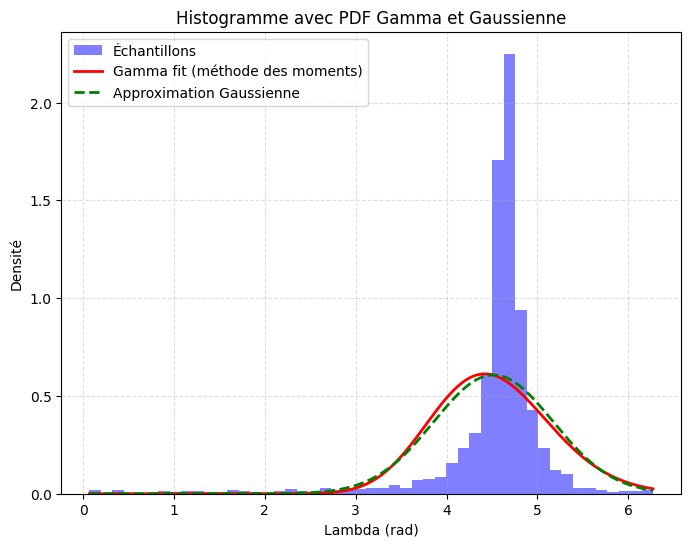

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

# Tes données
data = lam_SNR_center

# Méthode des moments pour Gamma
mean = np.mean(data)
var = np.var(data, ddof=1)

k = mean**2 / var
theta = var / mean

# Histogramme normalisé de tes échantillons
plt.figure(figsize=(8,6))
bins = np.linspace(data.min(), data.max(), 50)
plt.hist(data, bins=bins, density=True, alpha=0.5, color='blue', label='Échantillons')

# PDF de la Gamma ajustée
x = np.linspace(data.min(), data.max(), 500)
pdf_gamma = gamma.pdf(x, a=k, scale=theta, loc=0)
plt.plot(x, pdf_gamma, 'r-', lw=2, label='Gamma fit (méthode des moments)')

# PDF de la Gaussienne approchée
sigma = np.sqrt(var)
print(mean, sigma)
pdf_gauss = norm.pdf(x, loc=mean, scale=sigma)
plt.plot(x, pdf_gauss, 'g--', lw=2, label='Approximation Gaussienne')

# Labels et légende
plt.xlabel("Lambda (rad)")
plt.ylabel("Densité")
plt.title("Histogramme avec PDF Gamma et Gaussienne")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()

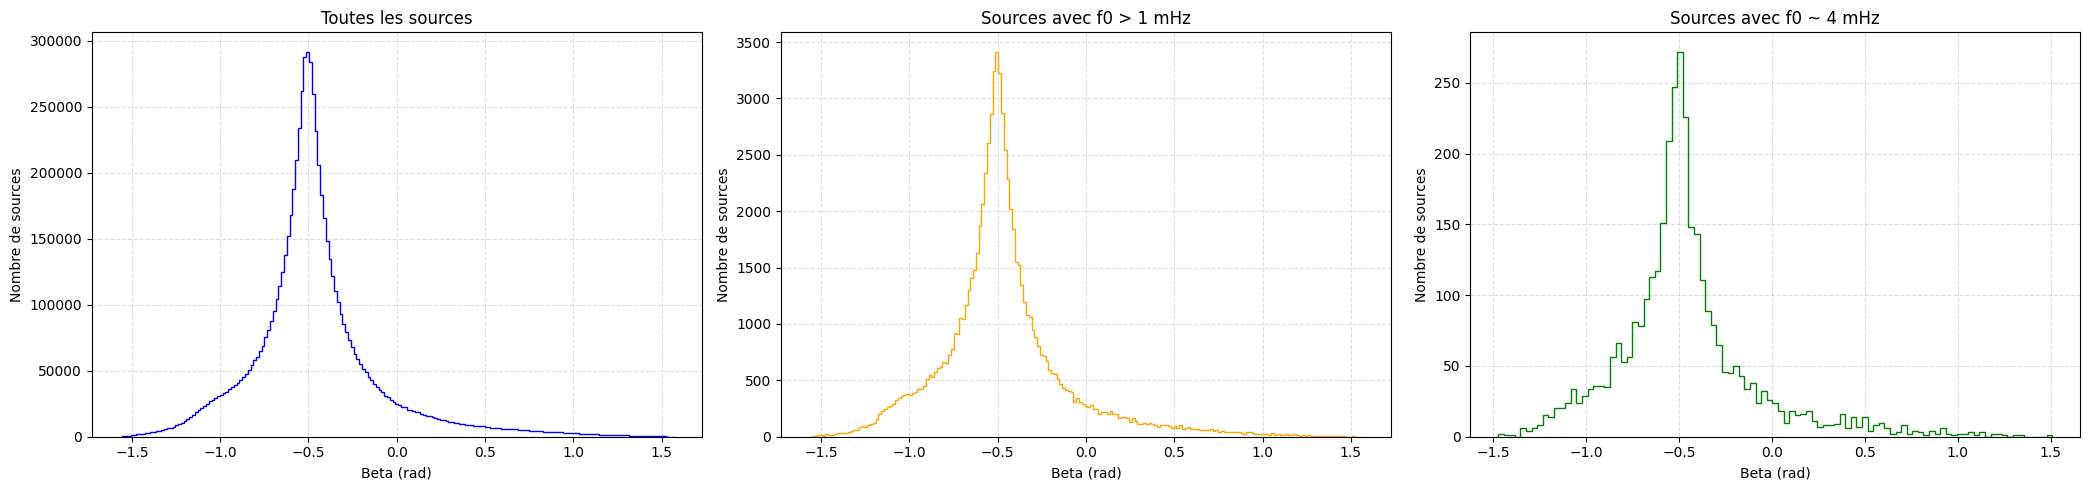

In [33]:


# Toutes les latitudes équatoriales
beta_all = beta

# Latitudes avec f0 > 1 mHz
threshold = 1e-3  # 1 mHz
mask = f0 > threshold
beta_high_f = beta[mask]

# Définir une fenêtre autour de 4 mHz
center = 4e-3       # 4 mHz
window = 1e-3       # ±1 mHz
mask_zoom = (f0 > (center - window)) & (f0 < (center + window))
beta_zoom = beta[mask_zoom]
beta_SNR_center = beta[(f0 > (center - window)) & (f0 < (center + window))  & (SNR > SNR_treshold)]


# Définir les bins linéaires (latitude peut être négative)
bins = np.linspace(beta_all.min(), beta_all.max(), 200)

# Créer la figure avec 3 sous-graphes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(21,5))

# Graphe 1 : toutes les latitudes
axes[0].hist(beta_all, bins=bins, histtype='step', color='blue')
axes[0].set_xlabel("Beta (rad)")
axes[0].set_ylabel("Nombre de sources")
axes[0].set_title("Toutes les sources")
axes[0].grid(True, ls="--", alpha=0.4)

# Graphe 2 : latitudes avec f0 > 1 mHz
axes[1].hist(beta_high_f, bins=bins, histtype='step', color='orange')
axes[1].set_xlabel("Beta (rad)")
axes[1].set_ylabel("Nombre de sources")
axes[1].set_title("Sources avec f0 > 1 mHz")
axes[1].grid(True, ls="--", alpha=0.4)

# Graphe 3 : latitudes avec f0 autour de 4 mHz
if len(beta_zoom) > 0:
    bins_zoom = np.linspace(beta_zoom.min(), beta_zoom.max(), 100)
    axes[2].hist(beta_zoom, bins=bins_zoom, histtype='step', color='green')
    axes[2].set_xlabel("Beta (rad)")
    axes[2].set_ylabel("Nombre de sources")
    axes[2].set_title("Sources avec f0 ~ 4 mHz")
    axes[2].grid(True, ls="--", alpha=0.4)
else:
    axes[2].text(0.5, 0.5, "Aucune source dans cette plage", ha='center', va='center')
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()


-0.461488966050874 0.3641616392060233


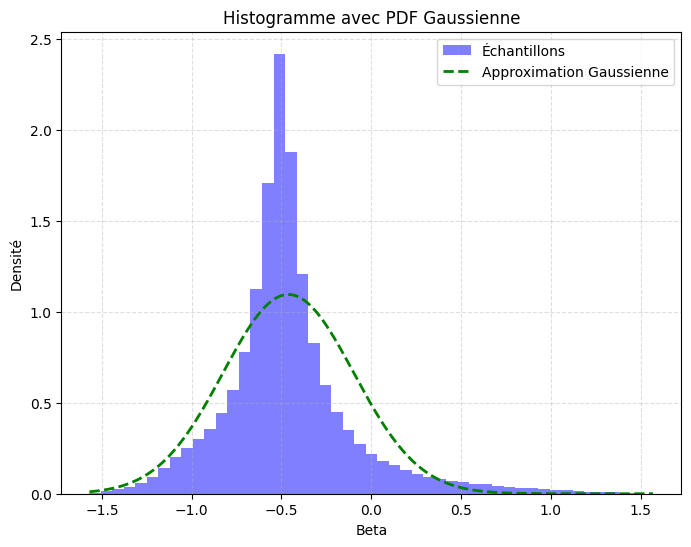

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Tes données
data = beta

# Moments
mean = np.mean(data)
var = np.var(data, ddof=1)
sigma = np.sqrt(var)

# Histogramme normalisé
plt.figure(figsize=(8,6))
bins = np.linspace(data.min(), data.max(), 50)
plt.hist(data, bins=bins, density=True, alpha=0.5, color='blue', label='Échantillons')

# PDF Gaussienne approchée
x = np.linspace(data.min(), data.max(), 500)
pdf_gauss = norm.pdf(x, loc=mean, scale=sigma)
plt.plot(x, pdf_gauss, 'g--', lw=2, label='Approximation Gaussienne')
print(mean, sigma)
# Labels et légende
plt.xlabel("Beta")
plt.ylabel("Densité")
plt.title("Histogramme avec PDF Gaussienne")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()

loc = 4.6487689300926816
scale = 0.12058123486346137


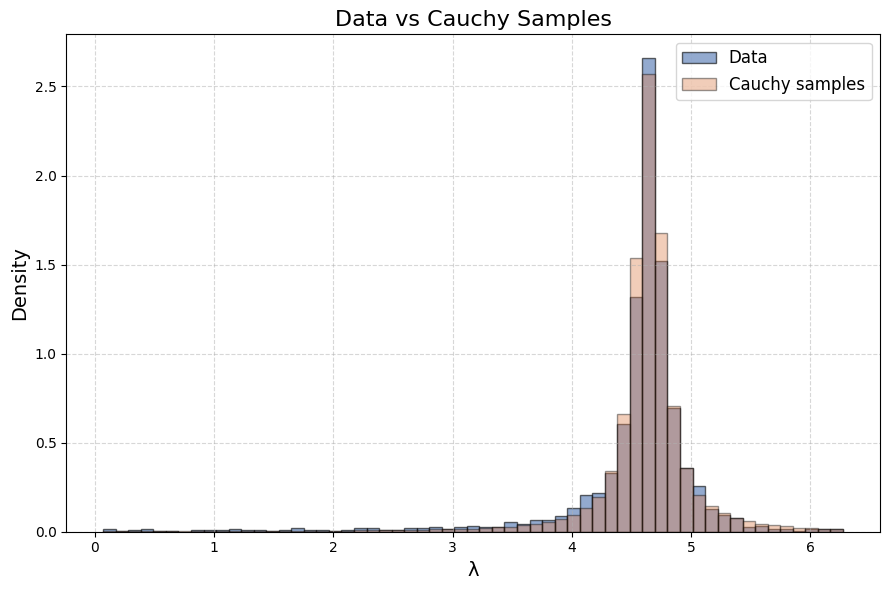

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import cauchy

# Données
data = lam_SNR_center

# Nombre d'échantillons
N = 100000

# Bins communs
bins = np.linspace(data.min(), data.max(), 60)

# Fit Cauchy
loc, scale = cauchy.fit(data)

print("loc =", loc)
print("scale =", scale)

# Générer échantillons Cauchy
samples = cauchy.rvs(loc=loc, scale=scale, size=N)

# Plot
plt.figure(figsize=(9,6))

# Histogramme données
plt.hist(
    data,
    bins=bins,
    density=True,
    alpha=0.6,
    color="#4C72B0",
    edgecolor="black",
    label="Data"
)

# Histogramme Cauchy samples
plt.hist(
    samples,
    bins=bins,
    density=True,
    alpha=0.4,
    color="#DD8452",
    edgecolor="black",
    label="Cauchy samples"
)

# Labels
plt.xlabel("λ", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Data vs Cauchy Samples", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

loc = -0.5094566583040998
scale = 0.13711223140007772


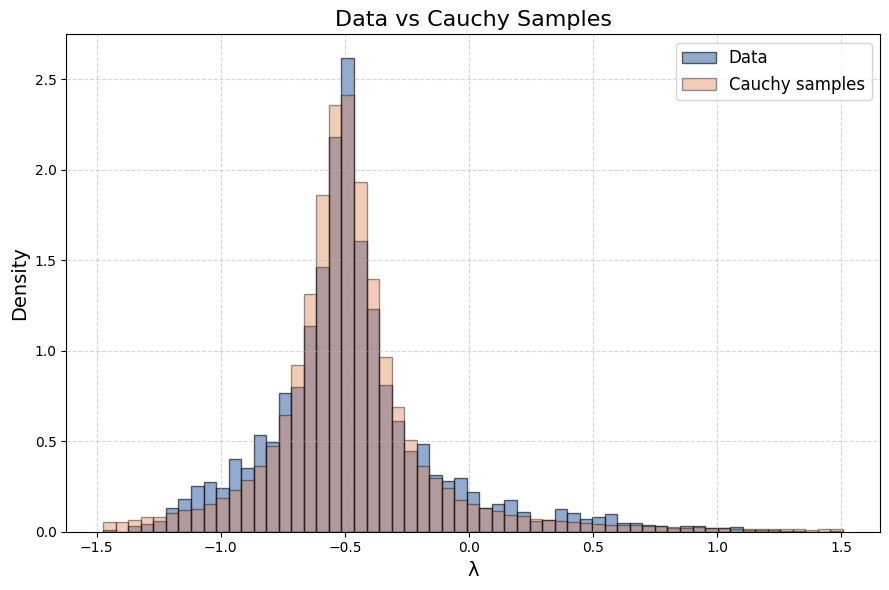

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import cauchy

# Données
data = beta_SNR_center

# Nombre d'échantillons
N = 100000

# Bins communs
bins = np.linspace(data.min(), data.max(), 60)

# Fit Cauchy
loc, scale = -0.5094566583040998, 0.13711223140007772

print("loc =", loc)
print("scale =", scale)

# Générer échantillons Cauchy
samples = cauchy.rvs(loc=loc, scale=scale, size=N)
# Plot
plt.figure(figsize=(9,6))

# Histogramme données
plt.hist(
    data,
    bins=bins,
    density=True,
    alpha=0.6,
    color="#4C72B0",
    edgecolor="black",
    label="Data"
)

# Histogramme Cauchy samples
plt.hist(
    samples,
    bins=bins,
    density=True,
    alpha=0.4,
    color="#DD8452",
    edgecolor="black",
    label="Cauchy samples"
)

# Labels
plt.xlabel("λ", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Data vs Cauchy Samples", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

loc = -0.504
scale = 0.241


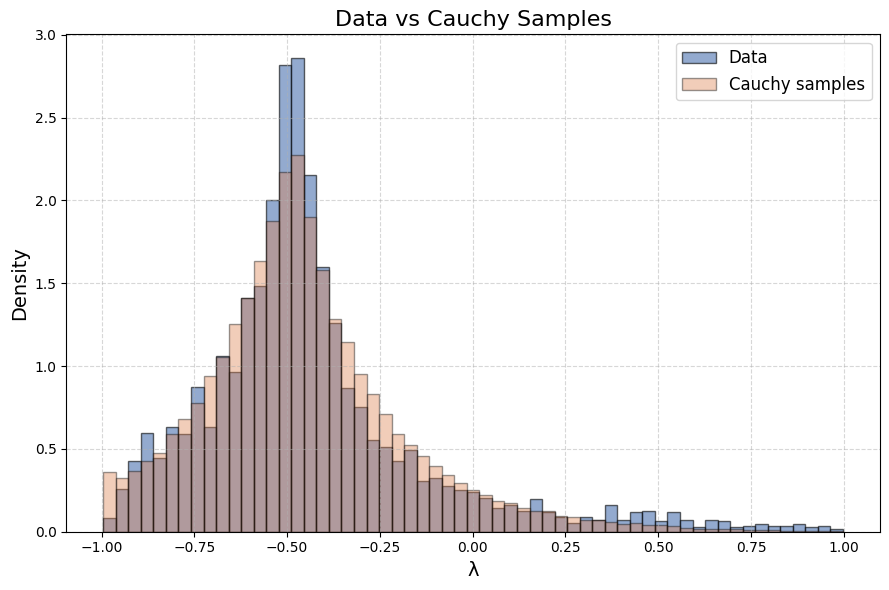

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import cauchy
from scipy.stats import laplace


# Données
data = beta_SNR_center
data = np.sin(data)  # Transformation pour rendre les données plus "Cauchy-like"
# Nombre d'échantillons
N = 100000

# Bins communs
bins = np.linspace(data.min(), data.max(), 60)

# Fit Cauchy
loc, scale = -0.504, 0.241

print("loc =", loc)
print("scale =", scale)

# Générer échantillons Cauchy
samples = np.random.laplace(loc=loc, scale=scale, size=N)
samples = np.sin(samples)  # Appliquer la même transformation aux échantillons
# Plot
plt.figure(figsize=(9,6))

# Histogramme données
plt.hist(
    data,
    bins=bins,
    density=True,
    alpha=0.6,
    color="#4C72B0",
    edgecolor="black",
    label="Data"
)

# Histogramme Cauchy samples
plt.hist(
    samples,
    bins=bins,
    density=True,
    alpha=0.4,
    color="#DD8452",
    edgecolor="black",
    label="Cauchy samples"
)

# Labels
plt.xlabel("λ", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Data vs Cauchy Samples", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

Paramètres de la Cauchy :
loc (médiane) = -0.5094566583040998
scale (largeur) = 0.13711223140007772


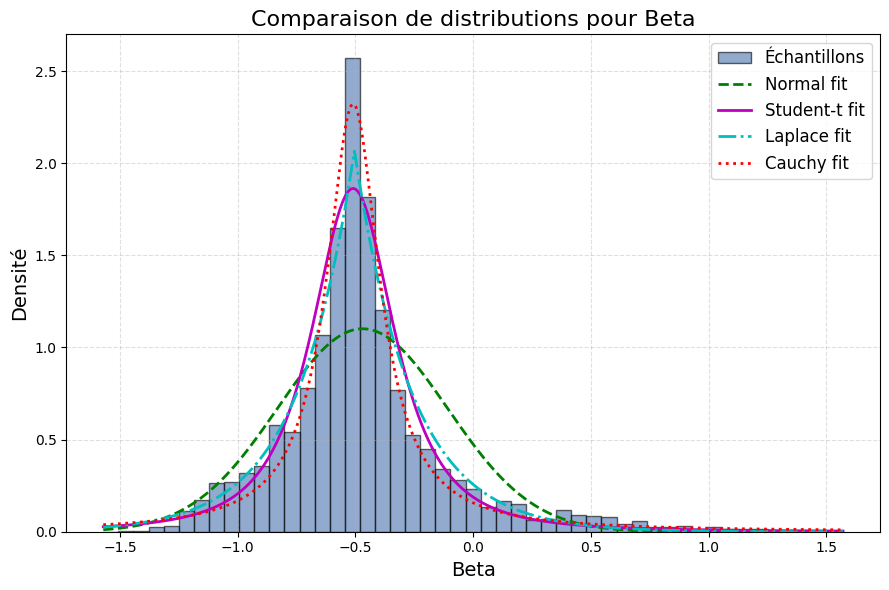

Normal: mu = -0.470, sigma = 0.362
Student-t: df = 2.045, loc = -0.510, scale = 0.190
Laplace: loc = -0.504, scale = 0.241
Cauchy: loc = -0.509, scale = 0.137


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t, laplace, cauchy

# Tes données
data = beta_SNR_center  # supposé déjà défini

# Histogramme normalisé avec bins fixes pour tout l'intervalle
lower, upper = -np.pi/2, np.pi/2
bins = np.linspace(lower, upper, 50)

plt.figure(figsize=(9,6))

# Histogramme des données
plt.hist(
    data,
    bins=bins,
    density=True,
    alpha=0.6,
    color='#4C72B0',
    edgecolor='black',
    label='Échantillons'
)

# Grille pour les PDF
x = np.linspace(lower, upper, 1000)

# Fit des distributions
params_norm = norm.fit(data)
params_t = t.fit(data)
params_laplace = laplace.fit(data)
params_cauchy = cauchy.fit(data)

loc, scale = params_cauchy

print("Paramètres de la Cauchy :")
print("loc (médiane) =", loc)
print("scale (largeur) =", scale)

# Tracé des PDF
plt.plot(x, norm.pdf(x, *params_norm), 'g--', lw=2, label='Normal fit')
plt.plot(x, t.pdf(x, *params_t), 'm-', lw=2, label='Student-t fit')
plt.plot(x, laplace.pdf(x, *params_laplace), 'c-.', lw=2, label='Laplace fit')
plt.plot(x, cauchy.pdf(x, *params_cauchy), 'r:', lw=2, label='Cauchy fit')

# Labels et légende
plt.xlabel("Beta", fontsize=14)
plt.ylabel("Densité", fontsize=14)
plt.title("Comparaison de distributions pour Beta", fontsize=16)
plt.grid(True, ls='--', alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Affichage des paramètres estimés
print("Normal: mu = {:.3f}, sigma = {:.3f}".format(*params_norm))
print("Student-t: df = {:.3f}, loc = {:.3f}, scale = {:.3f}".format(*params_t))
print("Laplace: loc = {:.3f}, scale = {:.3f}".format(*params_laplace))
print("Cauchy: loc = {:.3f}, scale = {:.3f}".format(*params_cauchy))

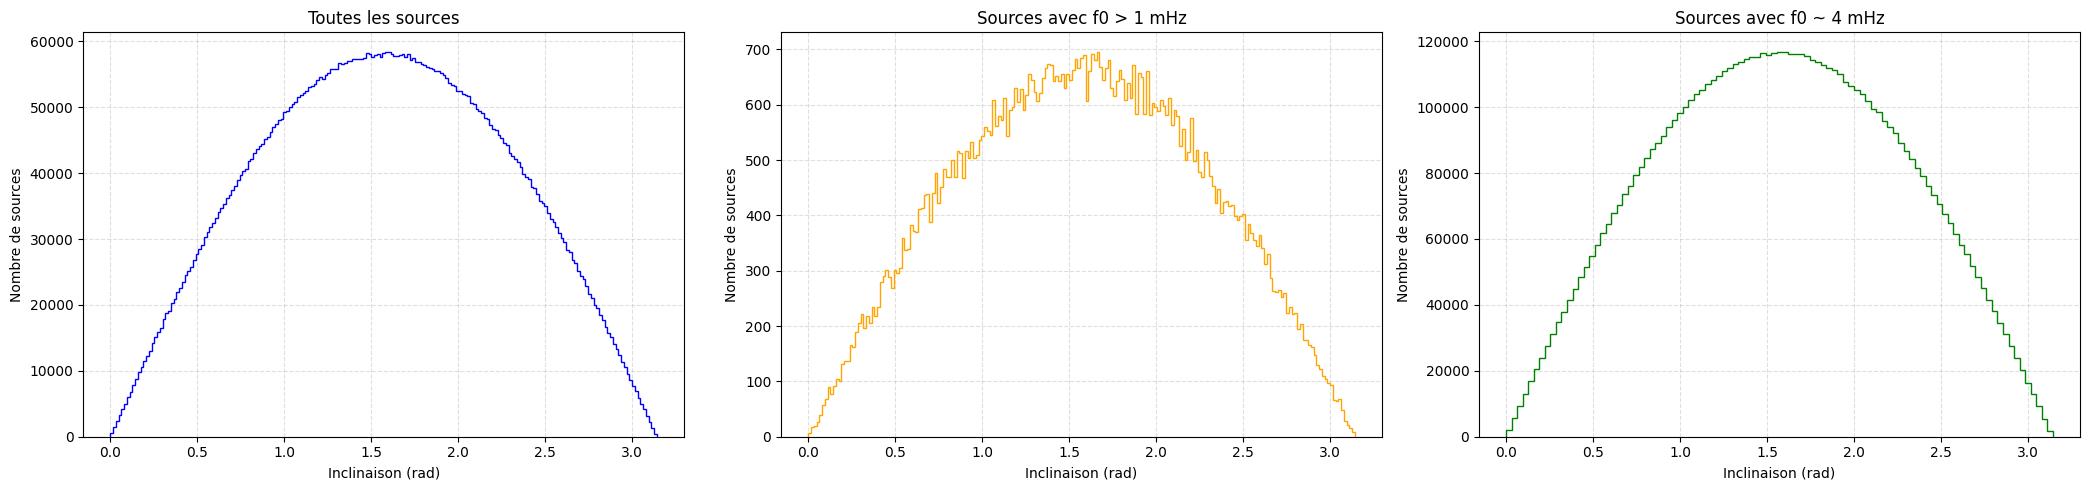

In [39]:

# Toutes les inclinaisons
iota_all = iota

# Inclinaisons avec f0 > 1 mHz
threshold = 1e-3  # 1 mHz
mask = f0 > threshold
iota_high_f = iota[mask]

# Définir une fenêtre autour de 4 mHz
center = 1e-3       # 4 mHz
window = 1e-3       # ±1 mHz
mask_zoom = (f0 > (center - window)) & (f0 < (center + window))
iota_zoom = iota[mask_zoom]

# Définir les bins linéaires (inclinaison entre 0 et pi)
bins = np.linspace(iota_all.min(), iota_all.max(), 200)

# Créer la figure avec 3 sous-graphes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(21,5))

# Graphe 1 : toutes les inclinaisons
axes[0].hist(iota_all, bins=bins, histtype='step', color='blue')
axes[0].set_xlabel("Inclinaison (rad)")
axes[0].set_ylabel("Nombre de sources")
axes[0].set_title("Toutes les sources")
axes[0].grid(True, ls="--", alpha=0.4)

# Graphe 2 : inclinaisons avec f0 > 1 mHz
axes[1].hist(iota_high_f, bins=bins, histtype='step', color='orange')
axes[1].set_xlabel("Inclinaison (rad)")
axes[1].set_ylabel("Nombre de sources")
axes[1].set_title("Sources avec f0 > 1 mHz")
axes[1].grid(True, ls="--", alpha=0.4)

# Graphe 3 : inclinaisons avec f0 autour de 4 mHz
if len(iota_zoom) > 0:
    bins_zoom = np.linspace(iota_zoom.min(), iota_zoom.max(), 100)
    axes[2].hist(iota_zoom, bins=bins_zoom, histtype='step', color='green')
    axes[2].set_xlabel("Inclinaison (rad)")
    axes[2].set_ylabel("Nombre de sources")
    axes[2].set_title("Sources avec f0 ~ 4 mHz")
    axes[2].grid(True, ls="--", alpha=0.4)
else:
    axes[2].text(0.5, 0.5, "Aucune source dans cette plage", ha='center', va='center')
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()




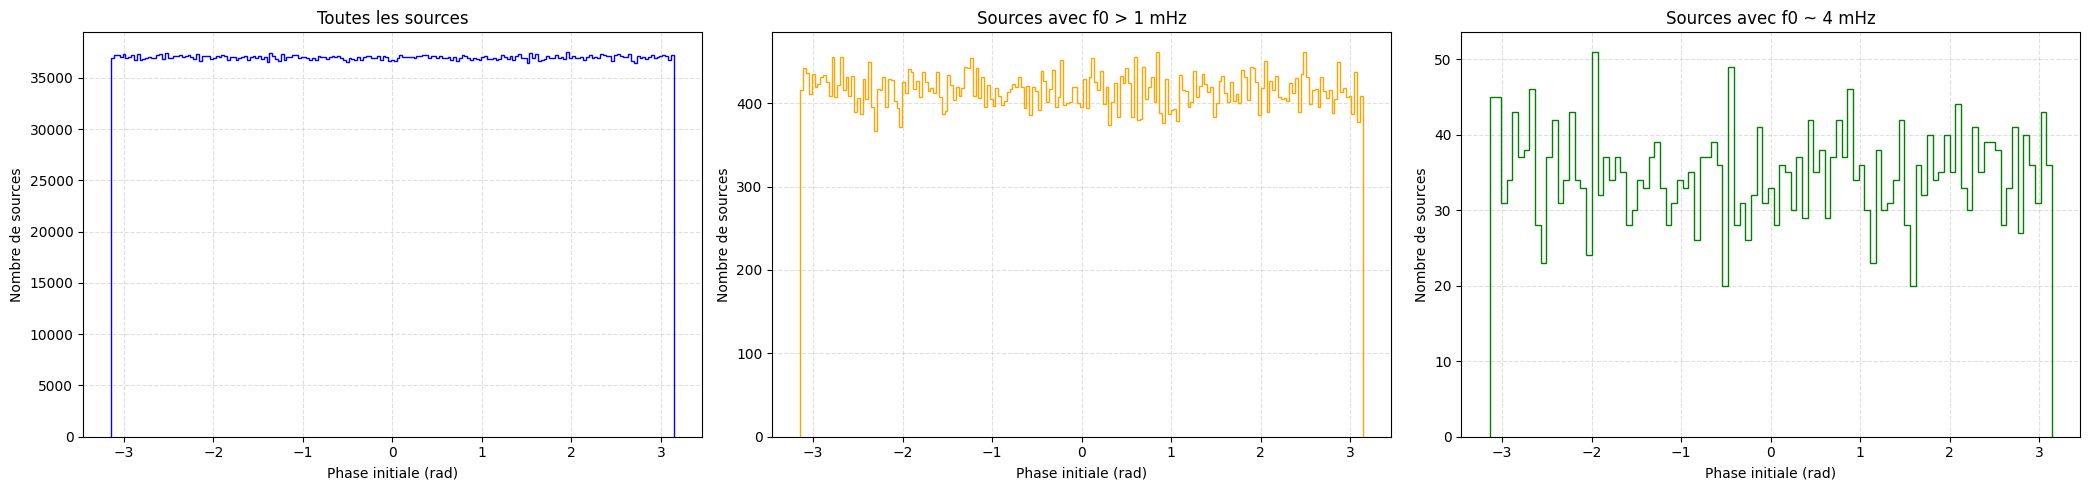

In [40]:

# Toutes les phases initiales
phi0_all = phi0

# Phases avec f0 > 1 mHz
threshold = 1e-3  # 1 mHz
mask = f0 > threshold
phi0_high_f = phi0[mask]

# Définir une fenêtre autour de 4 mHz
center = 4e-3       # 4 mHz
window = 1e-3       # ±1 mHz
mask_zoom = (f0 > (center - window)) & (f0 < (center + window))
phi0_zoom = phi0[mask_zoom]

# Définir les bins linéaires (phase entre 0 et 2π)
bins = np.linspace(phi0_all.min(), phi0_all.max(), 200)

# Créer la figure avec 3 sous-graphes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(21,5))

# Graphe 1 : toutes les phases
axes[0].hist(phi0_all, bins=bins, histtype='step', color='blue')
axes[0].set_xlabel("Phase initiale (rad)")
axes[0].set_ylabel("Nombre de sources")
axes[0].set_title("Toutes les sources")
axes[0].grid(True, ls="--", alpha=0.4)

# Graphe 2 : phases avec f0 > 1 mHz
axes[1].hist(phi0_high_f, bins=bins, histtype='step', color='orange')
axes[1].set_xlabel("Phase initiale (rad)")
axes[1].set_ylabel("Nombre de sources")
axes[1].set_title("Sources avec f0 > 1 mHz")
axes[1].grid(True, ls="--", alpha=0.4)

# Graphe 3 : phases avec f0 autour de 4 mHz
if len(phi0_zoom) > 0:
    bins_zoom = np.linspace(phi0_zoom.min(), phi0_zoom.max(), 100)
    axes[2].hist(phi0_zoom, bins=bins_zoom, histtype='step', color='green')
    axes[2].set_xlabel("Phase initiale (rad)")
    axes[2].set_ylabel("Nombre de sources")
    axes[2].set_title("Sources avec f0 ~ 4 mHz")
    axes[2].grid(True, ls="--", alpha=0.4)
else:
    axes[2].text(0.5, 0.5, "Aucune source dans cette plage", ha='center', va='center')
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()


In [41]:
# Toutes les polarisation
psi_all = psi

# Polarisation avec f0 > 1 mHz
threshold = 1e-3  # 1 mHz
mask = f0 > threshold
psi_high_f = psi[mask]

# Définir une fenêtre autour de 4 mHz
center = 4e-3       # 4 mHz
window = 1e-3       # ±1 mHz
mask_zoom = (f0 > (center - window)) & (f0 < (center + window))
psi_zoom = psi[mask_zoom]

# Définir les bins linéaires (polarisation entre 0 et pi)
bins = np.linspace(psi_all.min(), psi_all.max(), 200)

# Créer la figure avec 3 sous-graphes côte à côte
fig, axes = plt.subplots(1, 3, figsize=(21,5))

# Graphe 1 : toutes les polarisation
axes[0].hist(psi_all, bins=bins, histtype='step', color='blue')
axes[0].set_xlabel("Polarisation (rad)")
axes[0].set_ylabel("Nombre de sources")
axes[0].set_title("Toutes les sources")
axes[0].grid(True, ls="--", alpha=0.4)

# Graphe 2 : polarisation avec f0 > 1 mHz
axes[1].hist(psi_high_f, bins=bins, histtype='step', color='orange')
axes[1].set_xlabel("Polarisation (rad)")
axes[1].set_ylabel("Nombre de sources")
axes[1].set_title("Sources avec f0 > 1 mHz")
axes[1].grid(True, ls="--", alpha=0.4)

# Graphe 3 : polarisation avec f0 autour de 4 mHz
if len(psi_zoom) > 0:
    bins_zoom = np.linspace(psi_zoom.min(), psi_zoom.max(), 100)
    axes[2].hist(psi_zoom, bins=bins_zoom, histtype='step', color='green')
    axes[2].set_xlabel("Polarisation (rad)")
    axes[2].set_ylabel("Nombre de sources")
    axes[2].set_title("Sources avec f0 ~ 4 mHz")
    axes[2].grid(True, ls="--", alpha=0.4)
else:
    axes[2].text(0.5, 0.5, "Aucune source dans cette plage", ha='center', va='center')
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()


IndexError: boolean index did not match indexed array along axis 0; size of axis is 10000 but size of corresponding boolean axis is 7364527

In [ ]:
Mc = (m1 * m2)**(3/5) / (m1 + m2)**(1/5)
print(min(Mc), max(Mc))

0.16925006335120288 1.0043029705066833


In [ ]:
import numpy as np

G = 6.67430e-11        # m^3 kg^-1 s^-2
c = 299792458.0        # m s^-1
M_sun = 1.9885e30      # kg

def fdot(f, Mc):
 
    Mc_kg = Mc * M_sun
    
    prefactor = (96/5) * np.pi**(8/3)
    return prefactor * (G * Mc_kg / c**3)**(5/3) * f**(11/3)

f_min = 0.004821699107149872 - 10e-6
f_max = 0.004821699107149872 + 10e-6
Mc_min = min(Mc)
Mc_max = max(Mc)

fdot_min = fdot(f_min, Mc_min)
fdot_max = fdot(f_max, Mc_max)

# Affichage d'un ordre de grandeur
print(f"fdot min = {fdot_min} Hz/s")
print(f"fdot max = {fdot_max} Hz/s")


fdot min = 9.53071168092147e-17 Hz/s
fdot max = 1.882017748809954e-15 Hz/s


In [ ]:
max(m1)

np.float64(1.4399240016937256)